<a href="https://colab.research.google.com/github/ValbertoFeitosa/cervical-cancer-machine-learning/blob/main/PrimeiroTrabalhoPacoteEstat%C3%ADstico_cervical_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nosso trabalho consiste em treinar diferentes modelos de aprendizado de máquina (ML) e comparar seus resultados na previsão do teste de Schiller.

# Sobre o DataSet

O conjunto de dados foi coletado no Hospital Universitario de Caracas, localizado em Caracas, Venezuela. Ele inclui informações demográficas, hábitos e históricos médicos de 858 pacientes. Vale destacar que vários pacientes optaram por não responder a algumas perguntas devido a preocupações com privacidade, resultando em valores ausentes.

**Variáveis**

(int) Age

(int) Number of sexual partners

(int) First sexual intercourse (age)

(int) Num of pregnancies

(bool) Smokes

(int) Smokes (years)

(int) Smokes (packs/year)

(bool) Hormonal Contraceptives

(int) Hormonal Contraceptives (years)

(bool) IUD

(int) IUD (years)

(bool) STDs

(int) STDs (number)

(bool) STDs:condylomatosis

(bool) STDs:cervical condylomatosis

(bool) STDs:vaginal condylomatosis

(bool) STDs:vulvo-perineal condylomatosis

(bool) STDs:syphilis

(bool) STDs:pelvic inflammatory disease

(bool) STDs:genital herpes

(bool) STDs:molluscum contagiosum

(bool) STDs:AIDS

(bool) STDs:HIV

(bool) STDs:Hepatitis B

(bool) STDs:HPV

(int) STDs: Number of diagnosis

(int) STDs: Time since first diagnosis

(int) STDs: Time since last diagnosis

(bool) Dx:Cancer

(bool) Dx:CIN

(bool) Dx:HPV

(bool) Dx

(bool) Hinselmann: target variable

(bool) Schiller: target variable

(bool) Cytology: target variable

(bool) Biopsy: target variable

Link para o dataset: https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors

**Licença:**

Este conjunto de dados está licenciado sob a licença Creative Commons Attribution 4.0 International (CC BY 4.0).

Isso permite o compartilhamento e a adaptação do conjunto de dados para qualquer finalidade, desde que seja dado o devido crédito ao autor.


Fernandes, K., Cardoso, J., & Fernandes, J. (2017). Cervical Cancer (Risk Factors) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5Z310.



# Teste de Schiller

O teste de Schiller é um procedimento ginecológico simples utilizado para identificar áreas suspeitas de lesões no colo do útero. Desenvolvido pelo médico Walter Schiller na década de 1930, o método consiste em aplicar uma solução de lugol (à base de iodo) sobre o tecido cervical. A lógica do exame é que células normais, ricas em glicogênio, absorvem o iodo e ficam escurecidas, enquanto células atípicas, como as cancerígenas ou pré-cancerígenas, não se coram adequadamente, permanecendo claras ou amareladas.
Procedimento:

O ginecologista utiliza uma zaragatoa (cotonete comprido) para aplicar o lugol no colo do útero, cobrindo toda a superfície.
Após a aplicação, o médico observa as áreas que não foram coradas pelo iodo, o que pode indicar a presença de células anormais.

**Interpretação dos Resultados:**

    Teste positivo: Áreas amareladas ou não coradas sugerem células atípicas que podem indicar lesões ou alterações celulares.
    Teste negativo: O colo do útero inteiro é uniformemente corado de marrom, indicando tecido saudável.

**Utilidade Clínica:**

**Vantagens:**
        Método barato, acessível em áreas com poucos recursos.
        Não possui efeitos colaterais significativos ou contraindicações absolutas (pacientes alérgicas ao iodo podem usar ácido acético como alternativa).

**Limitações:**
        Alta taxa de falsos positivos, especialmente em mulheres na menopausa ou com cervicite.
        Não é tão confiável quanto o exame de Papanicolau, que é o padrão atual de rastreio para o câncer cervical.

**Atualidade do Uso:**

Embora seu uso como exame de triagem tenha diminuído devido ao avanço de métodos como o Papanicolau e a pesquisa de HPV, o teste de Schiller ainda é empregado em contextos específicos, como durante colposcopias e biópsias, para auxiliar na identificação de áreas a serem examinadas. Em locais com menos recursos, o teste pode ser utilizado como alternativa viável para o rastreio inicial de câncer do colo do útero.

Fonte: https://www.mdsaude.com/ginecologia/teste-de-schiller/

# Passos em nosso trabalho:

## 1 - Remoção de Colunas Irrelevantes

Remova as seguintes colunas antes de iniciar qualquer análise, pois elas não devem ser consideradas como atributos:

    Hinselmann
    Cytology
    Biopsy

**Motivos:**

I. Dependência Direta com a Variável-Alvo (Teste de Schiller)

Essas variáveis são testes diagnósticos complementares ou utilizados na sequência do processo de triagem junto com o teste de Schiller.
Se essas variáveis fossem incluídas no modelo, ele poderia "aprender" a correlacionar diretamente seus resultados com a variável-alvo, o que representaria um viés no treinamento e invalidaria o objetivo preditivo.

II. Redundância e Interpretação Clínica

Como o objetivo é prever o resultado do teste de Schiller a partir de fatores de risco (variáveis preditivas), usar outros exames diagnósticos como entradas violaria o propósito.
O uso dessas variáveis tornaria o modelo menos útil clinicamente, já que a previsão seria baseada em informações que só estariam disponíveis após o teste de Schiller.

III. Boa Prática de Modelagem Preditiva

Modelos preditivos devem usar variáveis que estejam disponíveis antes de se realizar o teste-alvo.
Hinselmann, Cytology e Biopsy são variáveis que dependem de exames já realizados e, portanto, não são adequadas como preditores.


## 2 - Identificação e Seleção de Variáveis

Após a remoção das colunas irrelevantes, prosseguimos com a identificação das variáveis mais relevantes para o modelo.

**Metodologia:**

**Análise Quantitativa:**
    
Utilizamos gráficos box plot para avaliar as variáveis quantitativas, mantendo no modelo aquelas que apresentaram diferenças significativas entre as categorias 0 e 1. Também criamos gráficos de frequência para a variável Schiller, com o objetivo de verificar possíveis desbalanceamentos entre as classes, garantindo uma análise mais detalhada.

**Análise Qualitativa:**

Para as variáveis categóricas, consultamos especialistas e a literatura médica para determinar se havia relação com alterações no útero. As variáveis identificadas como relevantes foram mantidas no modelo.

**Eliminação de Variáveis Correlacionadas:**

Além disso, analisamos a correlação entre as variáveis, eliminando aquelas que apresentaram alta correlação entre si, de modo a evitar redundâncias e reduzir possíveis problemas de multicolinearidade no modelo.

**Pesquisas Complementares:**

A escolha das variáveis também foi embasada por pesquisa na literatura científica e consultas a profissionais especializados, assegurando que o modelo capturasse os principais fatores associados às alterações celulares no útero e ao câncer do colo do útero. Esse cuidado adicional reforça a relevância das variáveis selecionadas no contexto do problema em análise.

## 3 - Tratamento de Dados Faltantes

**Variáveis Quantitativas:** Os valores ausentes serão substituídos pela média,moda ou mediana da variável, caso a quantidade de dados ausentes seja relativamente pequena; caso contrário, a variável será eliminada.

**Variáveis Qualitativas:** Para valores ausentes em variáveis qualitativas pertencentes à classe positiva do teste de Schiller, e cuja quantidade seja relativamente pequena, esses valores serão substituídos pela categoria que aumenta a probabilidade de um resultado positivo no teste. De maneira semelhante, se os valores ausentes estiverem na classe negativa e forem poucos, eles serão preenchidos com a categoria que favoreça a classificação negativa. Contudo, se a quantidade de valores ausentes for significativa e não estiver relacionada à classe positiva do teste de Schiller, optaremos por eliminar os registros com dados ausentes, garantindo a qualidade e a integridade do conjunto de dados.

A exclusão de linhas com valores ausentes na categoria positiva do teste de Schiller será considerada apenas como último recurso, e somente se o impacto dessa exclusão for mínimo, devido à quantidade limitada de observações nesta classe (apenas 74 registros).

**Exemplificação:**

Suponha que estamos analisando a variável qualitativa "Fuma", que possui duas categorias: "Sim" e "Não". Além disso, sabemos que o hábito de fumar está associado a um aumento na probabilidade de um resultado positivo no teste de Schiller. Se a variável "Fuma" apresentar valores ausentes em registros onde o resultado do teste de Schiller é positivo, substituímos esses valores pela categoria "Sim".


## 4 - Balanceamento dos Dados

Dado que o conjunto de dados apresenta 784 observações na classe negativa e apenas 74 na classe positiva do teste de Schiller, diferentes abordagens de balanceamento foram realizadas para criar cenários mais equilibrados, garantindo análises mais robustas. As estratégias adotadas incluem:

**SMOTE Elevado**

Após o pré-processamento dos dados (tratamento de valores ausentes e seleção das variáveis relevantes), aplicamos o algoritmo de balanceamento SMOTE para aumentar o número de observações na classe minoritária (positiva), igualando-o ao número da classe majoritária (negativa).

**Objetivo:** Este método visa garantir a representatividade da classe positiva, equilibrando a quantidade de dados entre as duas classes. Isso ajuda a evitar viés em favor da classe majoritária durante o treinamento dos modelos.

**SMOTE com Redução por Seleção Aleatória**

Após o pré-processamento dos dados, aplicamos o SMOTE para aumentar o número de observações na classe minoritária (positiva) para o dobro da sua quantidade original. Em seguida, reduzimos o número de observações na classe majoritária (negativa), selecionando aleatoriamente um subconjunto com a mesma quantidade da classe positiva.

**Objetivo:** Este método cria um conjunto de dados equilibrado, minimizando possíveis artefatos introduzidos pelo excesso de amostras sintéticas geradas pelo SMOTE, enquanto reduz o impacto de dados redundantes na classe majoritária.

**SMOTE com Redução via Undersampling**
Após o pré-processamento, utilizamos o SMOTE para aumentar o número de observações na classe minoritária (positiva) para o dobro da quantidade original. Em seguida, aplicamos Undersampling à classe majoritária (negativa) para equilibrar as duas classes.

**Objetivo:** Além de equilibrar as classes, esta abordagem combina os benefícios do SMOTE e do Undersampling, garantindo que o balanceamento seja atingido de forma eficiente. Isso ajuda a lidar com a redundância de dados na classe majoritária e, ao mesmo tempo, aumenta a representatividade da classe minoritária.


*Essas diferentes estratégias foram testadas para avaliar o impacto no desempenho dos modelos preditivos, buscando identificar a melhor abordagem para balancear as classes sem comprometer a integridade do conjunto de dados.*

## 5 - Treinamento e Comparação dos Modelos

Realizamos o treinamento de diferentes modelos de aprendizado de máquina (ML) para prever os resultados do teste de Schiller, utilizando as variáveis selecionadas e os dados devidamente pré-processados. Para garantir a equidade na análise, aplicamos diversas combinações de técnicas de balanceamento, assegurando que os modelos fossem treinados em cenários equilibrados entre as classes, promovendo uma avaliação mais robusta e precisa.

As abordagens de balanceamento utilizadas, descritas no passo 4, foram:

    SMOTE Elevado
    SMOTE com Redução por Seleção Aleatória
    SMOTE com Redução via Undersampling:


**Etapas Realizadas:**

    Divisão do Conjunto de Dados:
    Dividimos os dados em conjuntos de treinamento e teste para garantir uma avaliação justa dos modelos.

    Modelos Utilizados

    Para avaliar o desempenho preditivo no teste de Schiller, utilizamos diferentes algoritmos de aprendizado
    de máquina, configurados com parâmetros específicos para garantir resultados consistentes.
    Os modelos aplicados foram:

    Regressão Logística (LogisticRegression(random_state=42)): Um modelo linear que utiliza a função logística para prever a probabilidade das classes.

    Árvore de Decisão (DecisionTreeClassifier(random_state=42)): Um modelo baseado em divisões hierárquicas nos dados, ideal para problemas interpretáveis.

    Random Forest (RandomForestClassifier(random_state=42)): Um ensemble de árvores de decisão que utiliza bagging para melhorar a precisão e reduzir o risco de overfitting.

    K-Nearest Neighbors (KNN) (KNeighborsClassifier(n_neighbors=5)): Algoritmo baseado na proximidade entre os dados no espaço dimensional para realizar a classificação.

    XGBoost (XGBClassifier(eval_metric='logloss', random_state=42)): Um modelo baseado em boosting que constrói árvores sequenciais para melhorar iterativamente os erros residuais.

**Esses modelos foram escolhidos por sua diversidade metodológica, variando de abordagens lineares a métodos baseados em árvores e algoritmos de vizinhança, garantindo uma análise ampla e robusta do desempenho em diferentes cenários de balanceamento dos dados.**

**Reprodutibilidade nos Modelos de Aprendizado de Máquina**

A reprodutibilidade é essencial no aprendizado de máquina para garantir que os resultados possam ser replicados em execuções futuras. Na maioria dos modelos, isso é alcançado configurando o parâmetro random_state, que controla o gerador de números aleatórios utilizado em etapas como divisão de dados, inicialização de pesos e geração de amostras sintéticas.

No caso de algoritmos determinísticos, como o K-Nearest Neighbors (KNN), que não possuem o parâmetro random_state, a reprodutibilidade depende de:

    Controle da aleatoriedade nos dados de entrada, garantindo
    consistência na divisão dos dados (train_test_split) ou balanceamento (e.g., SMOTE) com random_state.
    Consistência no pré-processamento, mantendo a mesma ordem e estrutura dos dados em todas as execuções.

Esse controle cuidadoso assegura resultados consistentes, mesmo em modelos que não utilizam aleatoriedade intrínseca.



**Validação Cruzada e Métricas de Avaliação**

A validação cruzada é uma técnica essencial em aprendizado de máquina para avaliar o desempenho de modelos de forma confiável e robusta. No contexto deste trabalho, utilizamos a função cross_val_score da biblioteca scikit-learn para calcular a métrica de acurácia, que será usada como critério principal para comparar os modelos desenvolvidos.
Como funciona a validação cruzada

A validação cruzada divide os dados em múltiplos subconjuntos (folds), garantindo que todos os exemplos sejam usados tanto para treinamento quanto para teste em diferentes momentos. Usamos 10 folds (k-fold cross-validation), o que significa que:

    Os dados são divididos em 10 partes iguais (ou quase iguais).
    Em cada iteração, o modelo é treinado com 9 partes e testado na parte restante.

    O processo é repetido 10 vezes, com cada fold sendo usado uma vez como conjunto de teste.

Função cross_val_score

O cálculo da acurácia para cada fold é realizado automaticamente pela função cross_val_score, e os resultados são retornados em um array, onde cada elemento corresponde ao desempenho do modelo em uma iteração. A média dos valores desse array é utilizada como métrica final para representar o desempenho geral do modelo.
Por que a acurácia?

A acurácia mede a proporção de predições corretas sobre o total de predições realizadas. Apesar de ser uma métrica simples, é adequada neste estudo para avaliar o equilíbrio entre as classes após os processos de balanceamento, considerando o impacto das técnicas como SMOTE e Undersampling.
Vantagens do uso da validação cruzada

    Redução de viés: A validação cruzada utiliza todo o conjunto de dados, diminuindo o impacto de divisões específicas dos dados.

    Resultados confiáveis: Ao calcular a métrica em várias divisões, obtemos uma estimativa mais robusta da performance do modelo.

    Uso eficiente dos dados: Nenhum dado é desperdiçado; todos são usados tanto para treinamento quanto para teste.

**Resumo Validação Cruzada e Métricas de Avaliação**

Neste trabalho, utilizamos a função cross_val_score para realizar a validação cruzada e avaliar os modelos com base na acurácia média. Essa abordagem garante que os modelos sejam avaliados de forma justa e consistente, permitindo comparações confiáveis entre diferentes algoritmos e estratégias de balanceamento aplicadas aos dados.

## 6 - Resultados:

Selecionamos o modelo com o melhor desempenho geral e analisamos sua capacidade preditiva em prever corretamente os resultados do teste de Schiller.



# Acesando o Dataset

In [ ]:
# Importa o módulo drive da biblioteca google.colab, que permite acessar o Google Drive diretamente no ambiente do Google Colab.
from google.colab import drive

# Monta o Google Drive no diretório '/content/drive', criando um ponto de montagem local no sistema de arquivos do Colab.
# Isso permite que o usuário acesse arquivos do seu Google Drive como se estivessem em um diretório local.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importa a biblioteca pandas, usada para manipulação e análise de dados estruturados (DataFrames e Séries).
import pandas as pd

# Importa a biblioteca NumPy, essencial para computação numérica e manipulação de arrays multidimensionais.
import numpy as np

# Importa a biblioteca Seaborn, que facilita a criação de gráficos estatísticos e é integrada com o matplotlib.
import seaborn as sns

# Importa a biblioteca Matplotlib, usada para criar visualizações gráficas (gráficos de linhas, barras, etc.).
import matplotlib.pyplot as plt

# Importa a biblioteca Plotly Express, que permite criar gráficos interativos de forma simples e rápida.
import plotly.express as px

In [ ]:
# Lê o arquivo CSV localizado no Google Drive e carrega os dados em um DataFrame.
# Define o delimitador como ',' (vírgula) e considera valores '?' como ausentes (NaN).

df = pd.read_csv('/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/Trabalho01Cancer/risk_factors_cervical_cancer.csv',delimiter=',', na_values='?')

In [ ]:
# Exibe um resumo do DataFrame, incluindo o número de entradas, colunas, tipos de dados e valores não nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

### 1- Remoção de Colunas Irrelevantes

In [ ]:
# Lista de colunas a serem removidas
columns_to_remove = ['Hinselmann', 'Citology', 'Biopsy']

# Remoção das colunas do DataFrame
df = df.drop(columns=columns_to_remove, errors='ignore')

# Verificar se as colunas foram removidas
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [ ]:
# Exibe a frequência das classes da variável alvo 'Schiller', mostrando que a base de dados está desbalanceada.
# Há 784 registros para a classe '0' e apenas 74 registros para a classe '1'.
# Isso indica um problema de desbalanceamento que deve ser tratado com cuidado, pois pode afetar negativamente o desempenho de modelos preditivos.
df['Schiller'].value_counts()

,count
Schiller,
0,784
1,74


In [ ]:
# Substituir valores na coluna Schiller
df['Schiller'] = df['Schiller'].replace({0: 'Negativo', 1: 'Positivo'})

# Verificar as alterações
print(df['Schiller'].value_counts())


Schiller
Negativo    784
Positivo     74
Name: count, dtype: int64


In [ ]:
# Imprime a soma dos valores ausentes (NaN) em cada coluna do DataFrame, permitindo identificar onde há dados faltantes.
print(df.isnull().sum())


Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

In [ ]:
# Exibe os tipos de dados de cada coluna do DataFrame, ajudando a entender como os dados estão armazenados (ex.: int, float, object).
print(df.dtypes)


Age                                     int64
Number of sexual partners             float64
First sexual intercourse              float64
Num of pregnancies                    float64
Smokes                                float64
Smokes (years)                        float64
Smokes (packs/year)                   float64
Hormonal Contraceptives               float64
Hormonal Contraceptives (years)       float64
IUD                                   float64
IUD (years)                           float64
STDs                                  float64
STDs (number)                         float64
STDs:condylomatosis                   float64
STDs:cervical condylomatosis          float64
STDs:vaginal condylomatosis           float64
STDs:vulvo-perineal condylomatosis    float64
STDs:syphilis                         float64
STDs:pelvic inflammatory disease      float64
STDs:genital herpes                   float64
STDs:molluscum contagiosum            float64
STDs:AIDS                         

### 2- Identificação e Seleção de Variáveis

A variável idade não possuía valores ausentes.
No gráfico box plot, apresentou diferenças significativas entre as categorias 0 (Negativo) e 1 (Positivo) do teste de Schiller, sendo, portanto, incluída no modelo.

<ipython-input-171-f4d1b6186d41>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Schiller', y='Age', palette='Set2')


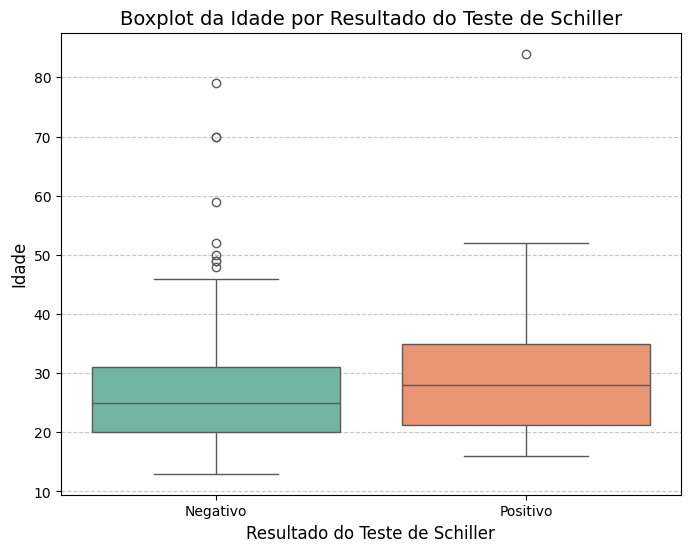

In [ ]:
# Criar o boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Schiller', y='Age', palette='Set2')

# Configurações do gráfico
plt.title('Boxplot da Idade por Resultado do Teste de Schiller', fontsize=14)
plt.xlabel('Resultado do Teste de Schiller', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()


As variáveis (int) Number of sexual partners, (int) First sexual intercourse (age) e (int) Num of pregnancies apresentavam valores ausentes, que foram substituídos pela média. Após análise dos gráficos box plot, apenas a variável Num of pregnancies mostrou diferenças significativas entre as categorias 0 (Negativo) e 1 (Positivo) do teste de Schiller, sendo, portanto, incluída no modelo.

In [ ]:
# Lista de variáveis a serem verificadas
variables_to_check = ['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies']

# Verificar valores ausentes para cada variável
for var in variables_to_check:
    if var in df.columns:  # Verifica se a variável existe no DataFrame
        missing_count = df[var].isnull().sum()
        print(f"Variável '{var}': {missing_count} valores ausentes.")
    else:
        print(f"A coluna '{var}' não está no DataFrame.")


Variável 'Number of sexual partners': 26 valores ausentes.
Variável 'First sexual intercourse': 7 valores ausentes.
Variável 'Num of pregnancies': 56 valores ausentes.


In [ ]:
# Lista de variáveis quantitativas com valores ausentes
variables_with_missing = ['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies']

# Substituir valores ausentes pela média de cada variável
for var in variables_with_missing:
    if var in df.columns:  # Verifica se a coluna existe no DataFrame
        df[var].fillna(df[var].mean(), inplace=True)
        print(f"Valores ausentes na variável '{var}' substituídos pela média: {df[var].mean():.2f}")
    else:
        print(f"A coluna '{var}' não está no DataFrame.")


Valores ausentes na variável 'Number of sexual partners' substituídos pela média: 2.53
Valores ausentes na variável 'First sexual intercourse' substituídos pela média: 17.00
Valores ausentes na variável 'Num of pregnancies' substituídos pela média: 2.28


<ipython-input-173-a75ef9aedbb5>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[var].fillna(df[var].mean(), inplace=True)


In [ ]:
# Lista de variáveis a serem verificadas
variables_to_check = ['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies']

# Verificar valores ausentes para cada variável
for var in variables_to_check:
    if var in df.columns:  # Verifica se a variável existe no DataFrame
        missing_count = df[var].isnull().sum()
        print(f"Variável '{var}': {missing_count} valores ausentes.")
    else:
        print(f"A coluna '{var}' não está no DataFrame.")


Variável 'Number of sexual partners': 0 valores ausentes.
Variável 'First sexual intercourse': 0 valores ausentes.
Variável 'Num of pregnancies': 0 valores ausentes.


<ipython-input-175-a5244e20f576>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Schiller', y=var, palette='Set2')


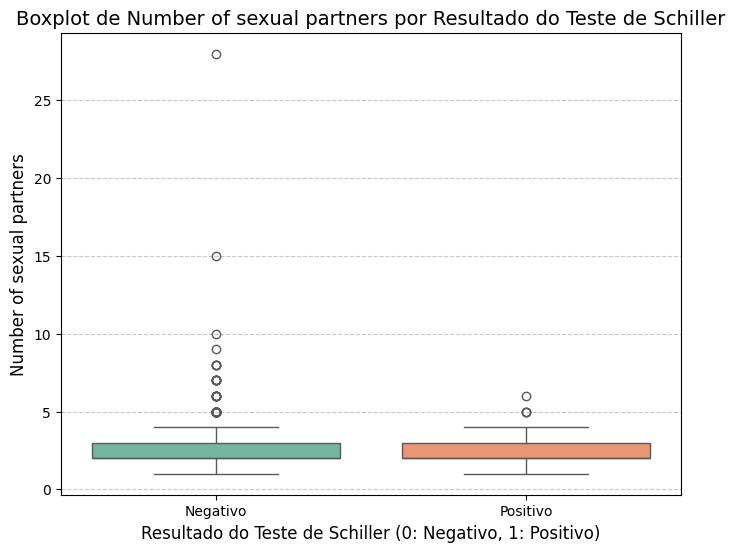

<ipython-input-175-a5244e20f576>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Schiller', y=var, palette='Set2')


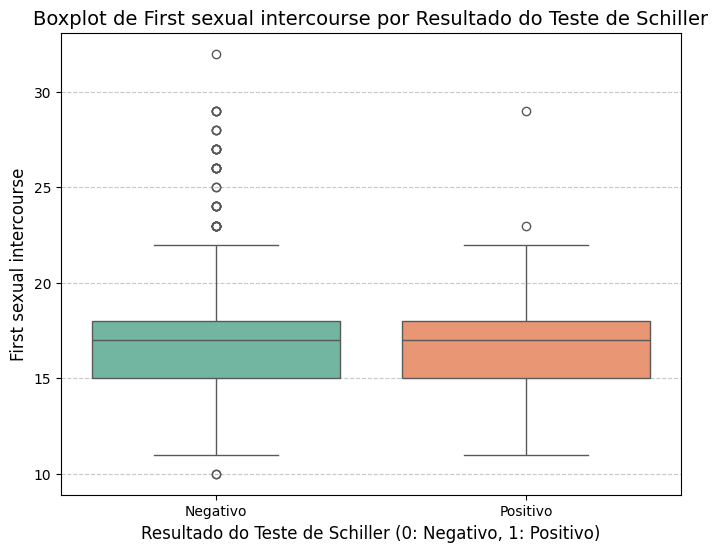

<ipython-input-175-a5244e20f576>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Schiller', y=var, palette='Set2')


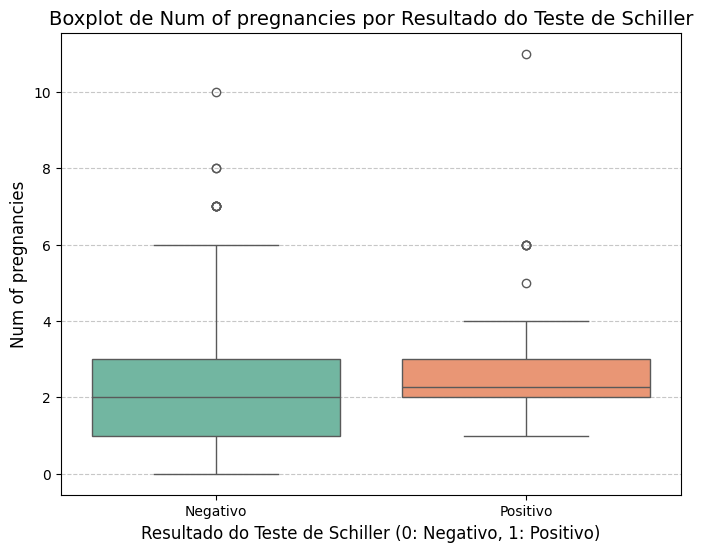

In [ ]:
# Lista de variáveis para análise
variables = ['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies']

# Criar um boxplot para cada variável
for var in variables:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='Schiller', y=var, palette='Set2')
    plt.title(f'Boxplot de {var} por Resultado do Teste de Schiller', fontsize=14)
    plt.xlabel('Resultado do Teste de Schiller (0: Negativo, 1: Positivo)', fontsize=12)
    plt.ylabel(var, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


A variável **Smokes (packs/year)** apresentou 13 valores ausentes, conforme indicado na tabela abaixo. O hábito de fumar está fortemente associado a alterações celulares no útero, incluindo o desenvolvimento de câncer do colo do útero, o que torna essa variável essencial para o modelo preditivo. Além disso, ela carrega informações importantes relacionadas ao comportamento de risco, contribuindo significativamente para a análise e previsão.

Para tratar os valores ausentes, adotamos o seguinte critério:

Dado que a representatividade dos valores ausentes é baixa (13 casos), distribuídos conforme indicado a seguir:

Valores ausentes na variável 'Smokes (packs/year)' por classe de 'Schiller':
Schiller
Negativo    11
Positivo     2

E considerando que o valor 0 é o mais frequente na distribuição observada no histograma da variável, decidimos substituí-los por 0. Essa abordagem é consistente com a análise exploratória e preserva a integridade do conjunto de dados.

Fonte:

Coelho FRG, Soares FA, Focchi J, et al. Câncer de colo do útero. Primeira edição. São Paulo: Tecmedd; 2008

https://prp.unicamp.br/pibic/congressos/xixcongresso/paineis/093057.pdf

In [ ]:
# Exibe os valores únicos presentes na variável 'Smokes (packs/year)'.
unique_values = df['Smokes (packs/year)'].unique()
print("Valores únicos de 'Smokes (packs/year)':")
print(unique_values)


Valores únicos de 'Smokes (packs/year)':
[0.00000000e+00 3.70000000e+01 3.40000000e+00 2.80000000e+00
 4.00000000e-02 5.13202128e-01 2.40000000e+00 6.00000000e+00
            nan 9.00000000e+00 1.60000000e+00 1.90000000e+01
 2.10000000e+01 3.20000000e-01 2.60000000e+00 8.00000000e-01
 1.50000000e+01 2.00000000e+00 5.70000000e+00 1.00000000e+00
 3.30000000e+00 3.50000000e+00 1.20000000e+01 2.50000000e-02
 2.75000000e+00 2.00000000e-01 1.40000000e+00 5.00000000e+00
 2.10000000e+00 7.00000000e-01 1.20000000e+00 7.50000000e+00
 1.25000000e+00 3.00000000e+00 7.50000000e-01 1.00000000e-01
 8.00000000e+00 2.25000000e+00 3.00000000e-03 7.00000000e+00
 4.50000000e-01 1.50000000e-01 5.00000000e-02 2.50000000e-01
 4.80000000e+00 4.50000000e+00 4.00000000e-01 3.70000000e-01
 2.20000000e+00 1.60000000e-01 9.00000000e-01 2.20000000e+01
 1.35000000e+00 5.00000000e-01 2.50000000e+00 4.00000000e+00
 1.30000000e+00 1.65000000e+00 2.70000000e+00 1.00000000e-03
 7.60000000e+00 5.50000000e+00 3.00000000e-0

In [ ]:
# Transformando em Inteiro
# Arredonda os valores e converte para inteiro, mantendo os NaN
df['Smokes (packs/year)'] = df['Smokes (packs/year)'].round(0).astype('Int64')

# Verifica a conversão
print(df['Smokes (packs/year)'].dtypes)



Int64


In [ ]:
# Conta o número de valores ausentes (NaN) na coluna 'Smokes (packs/year)'.
# Isso ajuda a identificar a quantidade de dados faltantes nesta variável, o que pode exigir técnicas de imputação ou exclusão para tratar esses valores.
df['Smokes (packs/year)'].isnull().sum()

13

In [ ]:
# Verificar valores ausentes na variável 'Smokes (packs/year)' por classe da variável 'Schiller'
missing_by_class = df[df['Smokes (packs/year)'].isnull()].groupby('Schiller').size()

# Exibir os resultados
print("Valores ausentes na variável 'Smokes (packs/year)' por classe de 'Schiller':")
print(missing_by_class)


Valores ausentes na variável 'Smokes (packs/year)' por classe de 'Schiller':
Schiller
Negativo    11
Positivo     2
dtype: int64


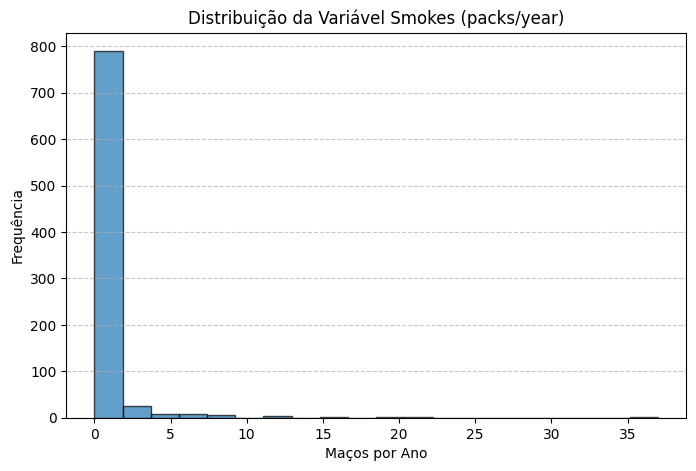

In [ ]:
# Criando o histograma para a variável 'Smokes (packs/year)'
plt.figure(figsize=(8, 5))
plt.hist(df['Smokes (packs/year)'].dropna(), bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribuição da Variável Smokes (packs/year)')
plt.xlabel('Maços por Ano')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Calcula a moda ignorando os valores ausentes (NaN)
mode_value = df['Smokes (packs/year)'].mode()[0]

# Substitui os valores ausentes pela moda calculada
df['Smokes (packs/year)'] = df['Smokes (packs/year)'].fillna(mode_value)

# Verifica se ainda há valores ausentes
print("Valores ausentes após substituição:", df['Smokes (packs/year)'].isnull().sum())

Valores ausentes após substituição: 0


In [ ]:
# Verificar valores ausentes na variável 'Smokes (packs/year)' por classe da variável 'Schiller'
missing_by_class = df[df['Smokes (packs/year)'].isnull()].groupby('Schiller').size()

# Exibir os resultados
print("Valores ausentes na variável 'Smokes (packs/year)' por classe de 'Schiller':")
print(missing_by_class)


Valores ausentes na variável 'Smokes (packs/year)' por classe de 'Schiller':
Series([], dtype: int64)


In [ ]:
# Exibe um resumo do DataFrame, incluindo o número de entradas, colunas, tipos de dados e valores não nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           858 non-null    float64
 2   First sexual intercourse            858 non-null    float64
 3   Num of pregnancies                  858 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 858 non-null    Int64  
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

Não incluímos as variáveis Smokes (years) e Smokes no modelo para evitar redundâncias e possíveis erros, já que ambas estão diretamente relacionadas à variável Smokes (packs/year). O consumo anual de maços está inevitavelmente associado ao hábito de fumar e à quantidade de anos de tabagismo. Assim, essas informações já estão representadas de forma implícita na variável Smokes (packs/year), tornando as outras variáveis desnecessárias para o modelo.

A variável Hormonal Contraceptives foi mantida no modelo devido à sua relação com alterações na camada interna do útero. Apesar de apresentar valores ausentes, nenhum deles está na categoria 1 (Schiller - Positiva). Esses valores ausentes correspondem a menos de 13% do total, resultando na exclusão de 108 registros - mas a frente.

Além disso, como existe uma relação direta entre as variáveis Hormonal Contraceptives e Hormonal Contraceptives (years), optamos por eliminar a última para evitar redundâncias no modelo.

Fonte: Consulta a profissionais da saúde.

Fonte: https://drlucascaseri.com.br/blog/contraceptivos-hormonais-consideracoes/?utm_source=chatgpt.com

Fonte: https://revista.unifaema.edu.br/index.php/Revista-FAEMA/article/view/1139/1060


In [ ]:
# Visualização em formato de Tabela
# Tabulação cruzada entre Hormonal Contraceptives e Schiller
cross_tab = pd.crosstab(df['Hormonal Contraceptives'], df['Schiller'], margins=True)

# Exibir a tabulação
print("Tabulação Cruzada - Hormonal Contraceptives x Schiller:")
print(cross_tab)


Tabulação Cruzada - Hormonal Contraceptives x Schiller:
Schiller                 Negativo  Positivo  All
Hormonal Contraceptives                         
0.0                           242        27  269
1.0                           434        47  481
All                           676        74  750


No contexto do seu dataset:
(bool) IUD

    Significado:
    Essa variável indica se a paciente utilizou um dispositivo intrauterino (DIU) em algum momento.
        Valor 1 (True): A paciente já utilizou DIU.
        Valor 0 (False): A paciente nunca utilizou DIU.

    Relevância no contexto médico:
    O DIU é um método contraceptivo que pode ser hormonal ou de cobre. Sua presença no útero pode causar alterações locais, incluindo inflamação uterina ou alterações na camada endometrial.

(int) IUD (years)

    Significado:
    Essa variável representa o número de anos em que a paciente utilizou o DIU.

    Relevância no contexto médico:
    O tempo de uso do DIU pode estar relacionado a possíveis alterações ou complicações, como inflamação uterina crônica, alterações endometriais ou infecções.

Justificativa para Exclusão

Exclusão IUD (years)

A variável IUD (years) foi avaliada quanto à sua relação com Schiller, e o coeficiente de determinação (R²) obtido foi de 0.0063. Esse valor indica que apenas 0,63% da variabilidade em IUD (years) é explicada por Schiller, o que demonstra uma relação extremamente fraca entre essas variáveis. Dessa forma, concluímos que IUD (years) é irrelevante para a análise preditiva e optamos por excluí-la do modelo para manter a simplicidade e eficácia


Exclusão de IUD

Para determinar o valor crítico do qui-quadrado em uma tabela 2x2, utilizamos um nível de significância de 0,05 (5%) e 1 grau de liberdade, o que resulta em um valor crítico de aproximadamente 3,8415. A estatística qui-quadrado obtida foi de 4,62, indicando que a relação entre as variáveis IUD e Schiller é estatisticamente significativa (p = 0.0316).

No entanto, embora a significância estatística tenha sido atingida, a magnitude da associação é muito baixa, como evidenciado pelas frequências observadas e esperadas, bem como pelo R² de 0.0063 obtido anteriormente. Esses resultados sugerem que, apesar da significância, a relação prática ou preditiva entre IUD e Schiller é mínima.

Além disso, a variável IUD apresenta um número significativo de valores ausentes (113), o que pode comprometer a robustez do modelo caso fosse incluída. Considerando esses fatores — impacto prático reduzido e alto volume de dados faltantes —, optamos por excluir a variável IUD do modelo para manter o foco em variáveis com maior relevância e qualidade de dados.

Fonte: BUSSAB, Wilton de O.; MORETTIN, Pedro A. Estatística básica. 5a edição. São Paulo: Saraiva, 2002.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Verificar se as colunas 'IUD (years)' e 'Schiller' estão no DataFrame
if 'IUD (years)' in df.columns and 'Schiller' in df.columns:
    # Ajustar o modelo de regressão
    modelo = ols('Q("IUD (years)") ~ C(Q("Schiller"))', data=df).fit()

    # Coeficiente de determinação (R²)
    r_squared = modelo.rsquared
    print("Coeficiente de determinação (R²) para IUD (years) e Schiller:", r_squared)
else:
    print("As variáveis 'IUD (years)' ou 'Schiller' não foram encontradas no DataFrame.")


Coeficiente de determinação (R²) para IUD (years) e Schiller: 0.006306789683862557


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Criar uma tabela de contingência entre IUD e Schiller
contingency_table = pd.crosstab(df['IUD'], df['Schiller'])

# Realizar o teste qui-quadrado
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Exibir os resultados
print("Tabela de Contingência:")
print(contingency_table)
print("\nResultados do Teste Qui-Quadrado:")
print(f"Qui-Quadrado: {chi2}")
print(f"p-valor: {p}")
print(f"Graus de Liberdade: {dof}")
print("\nFrequências Esperadas:")
print(expected)


Tabela de Contingência:
Schiller  Negativo  Positivo
IUD                         
0.0            600        58
1.0             69        14

Resultados do Teste Qui-Quadrado:
Qui-Quadrado: 4.569058367296383
p-valor: 0.032554454792450574
Graus de Liberdade: 1

Frequências Esperadas:
[[594.06477733  63.93522267]
 [ 74.93522267   8.06477733]]


In [ ]:
# Filtra os registros onde a coluna 'IUD' contém valores ausentes (NaN) e agrupa por classes da variável 'Schiller'.
# Conta a quantidade de valores ausentes em 'IUD' para cada classe de 'Schiller' (ex.: Negativo ou Positivo).
missing_by_class = df[df['IUD'].isnull()].groupby('Schiller').size()

# Exibe o resultado com a contagem de valores ausentes em 'IUD' para cada classe de 'Schiller'.
print("Valores ausentes na variável 'IUD' por classe de 'Schiller':")
print(missing_by_class)


Valores ausentes na variável 'IUD' por classe de 'Schiller':
Schiller
Negativo    115
Positivo      2
dtype: int64


O Que é o STDs:HPV?

Descrição Geral:

O HPV é um vírus de DNA que infecta a pele e as mucosas, podendo causar verrugas (condilomas) ou lesões mais graves, como alterações pré-cancerígenas e câncer.
Existem mais de 200 tipos de HPV, dos quais cerca de 40 podem infectar a região genital.

Classificação dos Tipos de HPV:

Baixo Risco: Associados a verrugas genitais e condilomas acuminados (ex.: HPV 6 e 11).
Alto Risco: Associados a alterações celulares que podem levar ao câncer cervical e outras formas de câncer (ex.: HPV 16 e 18).


Manteremos a variável HPV no modelo, pois ela representa um fator crucial para análises relacionadas à saúde do útero. Sua inclusão é essencial, especialmente na detecção e previsão de lesões ou condições associadas ao câncer cervical. Considerando sua relevância clínica e biológica no contexto, a variável HPV é indispensável para garantir a robustez e a eficácia do modelo preditivo.



Relação do HPV com as Variáveis:

    (bool) STDs:
        Essa variável indica se o indivíduo já teve alguma doença sexualmente transmissível.
        O HPV, sendo uma DST comum, está diretamente relacionado. Pacientes com histórico de DSTs têm maior probabilidade de infecção por HPV, especialmente em casos de múltiplos parceiros sexuais.

    (int) STDs (number):
        Representa o número de DSTs que o paciente teve.
        Indivíduos com múltiplas DSTs estão em maior risco de infecção por HPV, dado o comportamento de risco associado, como múltiplos parceiros sexuais e falta de uso de proteção.

    (bool) STDs:condylomatosis:
        Refere-se à presença de condilomas (verrugas genitais), que são frequentemente causados por tipos de HPV de baixo risco, como HPV 6 e 11.
        A relação aqui é direta, já que essas lesões são manifestações clássicas de infecções por HPV.

    (bool) STDs:cervical condylomatosis:
        Refere-se a condilomas especificamente no colo do útero.
        Também é diretamente associado ao HPV, que pode causar verrugas ou lesões pré-cancerígenas nessa região.

    (bool) STDs:vaginal condylomatosis:
        Refere-se a condilomas na vagina.
        Relacionado a infecções por HPV de baixo risco, que podem causar verrugas genitais nessa área.

    (bool) STDs:vulvo-perineal condylomatosis:
        Refere-se a condilomas na vulva ou região perineal.
        Esses tipos de condilomas também são frequentemente causados por HPV de baixo risco.

    (int) STDs: Number of diagnosis:
        Indica o número de diagnósticos de DSTs que o paciente recebeu.
        Pacientes com histórico de múltiplos diagnósticos de DSTs apresentam maior risco de infecção por HPV, devido a fatores comportamentais e exposição frequente.

    (int) STDs: Time since first diagnosis:
        Mede o tempo desde o primeiro diagnóstico de uma DST.
        Embora não haja uma ligação direta com o HPV, um tempo longo pode indicar uma história prolongada de comportamentos de risco, o que aumenta a probabilidade de infecção por HPV.

    (int) STDs: Time since last diagnosis:
        Mede o tempo desde o diagnóstico mais recente de uma DST.
        Sem uma relação direta com HPV, mas pode indicar a frequência recente de comportamentos de risco associados à exposição ao vírus.

Fonte: Pesquisa no Google a ChatGPT

As variáveis abaixo foram eliminadas por terem relação com HPV

(bool) STDs

(int) STDs (number)

(bool) STDs:condylomatosis

(bool) STDs:cervical condylomatosis

(bool) STDs:vaginal condylomatosis

(bool) STDs:vulvo-perineal condylomatosis

(int) STDs: Number of diagnosis

(int) STDs: Time since first diagnosis

(int) STDs: Time since last diagnosis

Exclusão das variáveis

STDs:AIDS	 - Indica diagnóstico de AIDS.
STDs:HIV	- Indica infecção pelo vírus HIV.
STDs:Hepatitis B - 	Indica infecção pelo vírus da Hepatite B.
STDs:molluscum contagiosum	- Indica presença de molusco contagioso.

As variáveis (bool) STDs:AIDS, (bool) STDs:HIV, (bool) STDs:Hepatitis B, e (bool) STDs:molluscum contagiosum foram eliminadas do modelo por não apresentarem relação significativa com doenças no útero. Embora algumas dessas condições possam influenciar indiretamente o sistema imunológico ou estejam associadas a DSTs, sua contribuição para o desenvolvimento de alterações no útero, como lesões ou câncer cervical, é irrelevante no contexto deste estudo.

Fonte: Google e ChatGPT

A variável Dx foi eliminada devido à falta de informações detalhadas sobre seu significado e relevância no contexto da análise, o que compromete sua contribuição para o modelo preditivo.

**As variáveis DxCancer, DxCIN e DxHPV foram excluídas do modelo devido aos seguintes motivos:**

Diagnósticos finais ou intermediários:
    
Essas variáveis representam resultados clínicos que poderiam introduzir viés preditivo no modelo, já que são mais consequência do que preditoras.

Ausência de independência como fatores de risco:
    
Elas não são fatores de risco independentes, mas sim resultados derivados de condições prévias, como infecções ou alterações celulares, já representadas por outras variáveis no modelo.

### 3- Tratamento de Dados Faltantes

1- STDs:syphilis

    Descrição:
        Refere-se à presença de sífilis, uma infecção sexualmente transmissível (DST) causada pela bactéria Treponema pallidum.
        A sífilis pode causar complicações sérias, incluindo lesões cutâneas, neurossífilis, e pode aumentar o risco de transmissão e progressão de outras infecções, como o HIV.

    Valores:
        1 (True): Indica que o paciente foi diagnosticado com sífilis.
        0 (False): Indica que o paciente nunca foi diagnosticado com sífilis.
        NaN: Indica ausência de informações sobre o diagnóstico.

    Relação com doenças do útero:
        Indireta. Embora a sífilis não afete diretamente o útero, comportamentos associados (como múltiplos parceiros ou práticas de risco) podem aumentar a exposição a outras DSTs, como o HPV, que tem impacto direto nas condições uterinas.

2- STDs:pelvic inflammatory disease (PID)

    Descrição:
        Refere-se à doença inflamatória pélvica (DIP), uma infecção que afeta os órgãos reprodutivos femininos, incluindo útero, trompas de Falópio e ovários.
        Geralmente é causada por infecções bacterianas associadas a DSTs, como a clamídia e a gonorreia.

    Valores:
        1 (True): O paciente já foi diagnosticado com PID.
        0 (False): O paciente nunca foi diagnosticado com PID.
        NaN: Indica ausência de informações sobre o diagnóstico.

    Relação com doenças do útero:
        Direta. A PID pode causar cicatrizes nas trompas de Falópio, inflamação crônica no útero e outros problemas que afetam a saúde reprodutiva.

3- STDs:genital herpes

    Descrição:
        Refere-se à presença de herpes genital, uma infecção sexualmente transmissível causada pelo vírus HSV-1 ou HSV-2.
        O herpes genital causa lesões ou úlceras na região genital e é recorrente.

    Valores:
        1 (True): O paciente foi diagnosticado com herpes genital.
        0 (False): O paciente nunca foi diagnosticado com herpes genital.
        NaN: Indica ausência de informações sobre o diagnóstico.

    Relação com doenças do útero:
        Indireta. O herpes genital não causa alterações diretas no útero, mas pode aumentar o risco de outras DSTs, incluindo o HPV, devido à quebra da barreira mucosa durante infecções ativas.

4- STDs:HPV

    Descrição:
        Refere-se à presença de papilomavírus humano (HPV), uma DST viral altamente prevalente.
        O HPV possui mais de 200 tipos, sendo alguns de baixo risco (causam verrugas) e outros de alto risco (associados ao câncer cervical).

    Valores:
        1 (True): O paciente foi diagnosticado com HPV.
        0 (False): O paciente nunca foi diagnosticado com HPV.
        NaN: Indica ausência de informações sobre o diagnóstico.

    Relação com doenças do útero:
        Direta. O HPV é a principal causa de câncer cervical e está fortemente associado a alterações pré-cancerígenas no colo do útero.

**As variáveis**

STDs:syphilis

STDs:pelvic inflammatory disease

STDs:genital herpes

STDs:HPV

Entram no modelo

As variáveis listadas abaixo apresentaram um total de 105 valores ausentes. Na categoria 1 de Schiller, todas elas tiveram apenas um dado faltante, curiosamente no mesmo índice (345). Considerando essa coincidência e a baixa representatividade dos dados ausentes na categoria positiva, optamos por eliminar os 105 valores ausentes.

STDs:syphilis

STDs:pelvic inflammatory disease

STDs:genital herpes

STDs:HPV

In [ ]:
# Lista das variáveis de interesse
variables = ['STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:HPV']

# Verificar dados ausentes por categoria de Schiller para as variáveis específicas
missing_by_schiller = df.groupby('Schiller')[variables].apply(lambda x: x.isnull().sum())

# Exibir os resultados
print("Quantidade de dados ausentes por categoria de Schiller:")
missing_by_schiller


Quantidade de dados ausentes por categoria de Schiller:


,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:HPV
Schiller,,,,
Negativo,104,104,104,104
Positivo,1,1,1,1


In [ ]:
# Criar uma tabela de referência cruzada entre Schiller e STDs:syphilis
cross_tab = pd.crosstab(df['Schiller'], df['STDs:syphilis'], margins=True)

# Exibir a tabela de referência cruzada
print("Tabela de Referência Cruzada: Schiller x STDs:syphilis")
print(cross_tab)


Tabela de Referência Cruzada: Schiller x STDs:syphilis
STDs:syphilis  0.0  1.0  All
Schiller                    
Negativo       664   16  680
Positivo        71    2   73
All            735   18  753


In [ ]:
# Lista das variáveis de interesse
variables = ['STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:HPV']

# Filtrar e visualizar as colunas de interesse onde há valores ausentes e Schiller é Positivo
missing_values_class_1 = df.loc[(df[variables].isnull().any(axis=1)) & (df['Schiller'] == 'Positivo'), ['Schiller'] + variables]

# Exibir os resultados
print("Linhas com valores ausentes nas variáveis selecionadas na classe 1 de Schiller:")
print(missing_values_class_1)


Linhas com valores ausentes nas variáveis selecionadas na classe 1 de Schiller:
     Schiller  STDs:syphilis  STDs:pelvic inflammatory disease  \
345  Positivo            NaN                               NaN   

     STDs:genital herpes  STDs:HPV  
345                  NaN       NaN  


In [ ]:
missing_values_class_1

,Schiller,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:HPV
345,Positivo,NaN,NaN,NaN,NaN


In [ ]:
# Lista das variáveis de interesse
variables = ['STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:HPV']

# Filtrar linhas onde 'Schiller' é 'Negativo' e pelo menos uma das variáveis apresenta NaN
rows_to_delete = df[(df['Schiller'] == 'Negativo') & (df[variables].isnull().any(axis=1))].index

# Remover as linhas do DataFrame
df = df.drop(rows_to_delete)

# Verificar o resultado
print(f"Linhas restantes no dataset: {len(df)}")
print("Valores ausentes após remoção:")
print(df[variables].isnull().sum())


Linhas restantes no dataset: 754
Valores ausentes após remoção:
STDs:syphilis                       1
STDs:pelvic inflammatory disease    1
STDs:genital herpes                 1
STDs:HPV                            1
dtype: int64


In [ ]:
# Lista das variáveis de interesse
variables = ['STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:HPV']

# Filtrar linhas onde 'Schiller' é 'Negativo' e pelo menos uma das variáveis apresenta NaN
rows_to_delete = df[(df['Schiller'] == 'Positivo') & (df[variables].isnull().any(axis=1))].index

# Remover as linhas do DataFrame
df = df.drop(rows_to_delete)

# Verificar o resultado
print(f"Linhas restantes no dataset: {len(df)}")
print("Valores ausentes após remoção:")
print(df[variables].isnull().sum())

Linhas restantes no dataset: 753
Valores ausentes após remoção:
STDs:syphilis                       0
STDs:pelvic inflammatory disease    0
STDs:genital herpes                 0
STDs:HPV                            0
dtype: int64


Inicialmente, a variável **Hormonal Contraceptives** apresentava 108 valores ausentes, sendo que nenhum deles estava na categoria 1 (Schiller - Positiva). Esses valores ausentes representavam menos de 1,72% do total. Após as exclusões anteriores, restaram apenas 13 valores ausentes, vamos exclui-los agora.

In [ ]:
# Conta o número de valores ausentes (NaN) na coluna 'Hormonal Contraceptives'.
# Isso ajuda a identificar a quantidade de dados faltantes nesta variável, que pode exigir tratamento específico.
df['Hormonal Contraceptives'].isnull().sum()


13

In [ ]:
# Lista das variáveis de interesse
variables = ['Hormonal Contraceptives']

# Filtrar linhas onde 'Schiller' é 'Negativo' e pelo menos uma das variáveis apresenta NaN
rows_to_delete = df[(df[variables].isnull().any(axis=1))].index

# Remover as linhas do DataFrame
df = df.drop(rows_to_delete)

# Verificar o resultado
print(f"Linhas restantes no dataset: {len(df)}")
print("Valores ausentes após remoção:")
print(df['Hormonal Contraceptives'].isnull().sum())

Linhas restantes no dataset: 740
Valores ausentes após remoção:
0


In [ ]:
# Conta o número de valores ausentes (NaN) na coluna 'Hormonal Contraceptives'.
# Isso ajuda a identificar a quantidade de dados faltantes nesta variável, que pode exigir tratamento específico.
df['Hormonal Contraceptives'].isnull().sum()

0

In [ ]:
# Exibe um resumo geral sobre o DataFrame `df`, incluindo:
# - O número total de entradas (linhas) no DataFrame.
# - A contagem de valores não nulos em cada coluna.
# - Os tipos de dados (dtype) de cada coluna.
# - O uso total de memória pelo DataFrame.
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 857
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 740 non-null    int64  
 1   Number of sexual partners           740 non-null    float64
 2   First sexual intercourse            740 non-null    float64
 3   Num of pregnancies                  740 non-null    float64
 4   Smokes                              732 non-null    float64
 5   Smokes (years)                      732 non-null    float64
 6   Smokes (packs/year)                 740 non-null    Int64  
 7   Hormonal Contraceptives             740 non-null    float64
 8   Hormonal Contraceptives (years)     740 non-null    float64
 9   IUD                                 734 non-null    float64
 10  IUD (years)                         734 non-null    float64
 11  STDs                                740 non-null  

### Variáveis que entram no Modelo



Variáveis que Entram no Modelo

Estas variáveis foram consideradas relevantes com base em sua relação direta ou significativa com o alvo (Schiller) ou sua relevância preditiva:

    (int) Age
        Justificativa: A idade pode ser um fator associado a alterações no útero.

    (int) Num of pregnancies
        Justificativa: Alterações no útero podem estar relacionadas ao número de gestações.

    (bool) Smokes (packs/year)
        Justificativa: O tabagismo está associado a alterações celulares no útero.

    (bool) Hormonal Contraceptives
        Justificativa: O uso de contraceptivos hormonais pode impactar a camada interna do útero.

    (bool) STDs:HPV
        Justificativa: Principal causa de câncer cervical, altamente relevante.

    (bool) STDs:syphilis
        Justificativa: Associado a comportamentos de risco que podem levar a infecções como o HPV.

    (bool) STDs:pelvic inflammatory disease
        Justificativa: Relacionado diretamente a inflamações no útero.

    (bool) STDs:genital herpes
        Justificativa: Pode facilitar infecções como HPV.

Age
Numofpregnancies
Smokes
HormonalContraceptives
STDssyphilis
STDspelvicinflammatorydisease
STDsgenitalherpes
STDsHPV


### 4- Balanceamento dos Dados

In [ ]:
# Lista das variáveis selecionadas
selected_variables = [
    'Age',
    'Num of pregnancies',
    'Smokes (packs/year)',
    'Hormonal Contraceptives',
    'STDs:HPV',
    'STDs:syphilis',
    'STDs:pelvic inflammatory disease',
    'STDs:genital herpes',
    #'IUD (years)',
    'Schiller'  # Incluindo a variável alvo
]

# Criar o novo DataFrame com as variáveis selecionadas
df_selected = df[selected_variables]

# Exibir as primeiras linhas do novo DataFrame para confirmação
print("Novo dataset com as variáveis selecionadas:")
print(df_selected.head())

# Verificar a estrutura do novo dataset
print("\nInformações do novo dataset:")
df_selected.info()


Novo dataset com as variáveis selecionadas:
   Age  Num of pregnancies  Smokes (packs/year)  Hormonal Contraceptives  \
0   18                 1.0                    0                      0.0   
1   15                 1.0                    0                      0.0   
2   34                 1.0                    0                      0.0   
3   52                 4.0                   37                      1.0   
4   46                 4.0                    0                      1.0   

   STDs:HPV  STDs:syphilis  STDs:pelvic inflammatory disease  \
0       0.0            0.0                               0.0   
1       0.0            0.0                               0.0   
2       0.0            0.0                               0.0   
3       0.0            0.0                               0.0   
4       0.0            0.0                               0.0   

   STDs:genital herpes  Schiller  
0                  0.0  Negativo  
1                  0.0  Negativo  
2        

In [ ]:
# O DataFrame `df_selected` contém as variáveis selecionadas após o processo de filtragem.
# As variáveis foram escolhidas com base em critérios como relevância para o modelo,
# evidências na literatura científica e análise de correlação para evitar redundâncias.
# Esse DataFrame representa o conjunto final de dados prontos para modelagem.
df_selected


,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
0,18,1.0,0,0.0,0.0,0.0,0.0,0.0,Negativo
1,15,1.0,0,0.0,0.0,0.0,0.0,0.0,Negativo
2,34,1.0,0,0.0,0.0,0.0,0.0,0.0,Negativo
3,52,4.0,37,1.0,0.0,0.0,0.0,0.0,Negativo
4,46,4.0,0,1.0,0.0,0.0,0.0,0.0,Negativo
...,...,...,...,...,...,...,...,...,...
853,34,0.0,0,0.0,0.0,0.0,0.0,0.0,Negativo
854,32,1.0,0,1.0,0.0,0.0,0.0,0.0,Negativo
855,25,0.0,0,1.0,0.0,0.0,0.0,0.0,Negativo
856,33,2.0,0,1.0,0.0,0.0,0.0,0.0,Negativo


In [ ]:
# Exibe informações sobre o DataFrame `df_selected`, incluindo:
# - O número total de entradas (linhas).
# - A quantidade de colunas.
# - Os nomes das colunas, tipos de dados e contagem de valores não nulos.
# - A memória usada pelo DataFrame.
df_selected.info()


<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 857
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               740 non-null    int64  
 1   Num of pregnancies                740 non-null    float64
 2   Smokes (packs/year)               740 non-null    Int64  
 3   Hormonal Contraceptives           740 non-null    float64
 4   STDs:HPV                          740 non-null    float64
 5   STDs:syphilis                     740 non-null    float64
 6   STDs:pelvic inflammatory disease  740 non-null    float64
 7   STDs:genital herpes               740 non-null    float64
 8   Schiller                          740 non-null    object 
dtypes: Int64(1), float64(6), int64(1), object(1)
memory usage: 58.5+ KB


In [ ]:
# Itera sobre todas as colunas do DataFrame `df_selected` e exibe:
# - O nome da coluna.
# - Os valores únicos presentes em cada coluna, permitindo a identificação
#   de categorias ou variações nos dados.
for column in df_selected.columns:
    print(f"Valores únicos na variável '{column}':")
    print(df_selected[column].unique())
    print()


Valores únicos na variável 'Age':
[18 15 34 52 46 42 51 26 45 44 27 43 40 41 39 37 38 36 35 33 31 32 30 23
 28 29 25 21 24 22 20 48 19 17 16 14 59 79 84 47 13 70 50 49]

Valores únicos na variável 'Num of pregnancies':
[ 1.         4.         2.         6.         3.         5.
  2.2755611  8.         7.         0.        11.        10.       ]

Valores únicos na variável 'Smokes (packs/year)':
<IntegerArray>
[0, 37, 3, 1, 2, 6, 9, 19, 21, 15, 4, 12, 8, 7, 5, 22]
Length: 16, dtype: Int64

Valores únicos na variável 'Hormonal Contraceptives':
[0. 1.]

Valores únicos na variável 'STDs:HPV':
[0. 1.]

Valores únicos na variável 'STDs:syphilis':
[0. 1.]

Valores únicos na variável 'STDs:pelvic inflammatory disease':
[0. 1.]

Valores únicos na variável 'STDs:genital herpes':
[0. 1.]

Valores únicos na variável 'Schiller':
['Negativo' 'Positivo']



In [ ]:
# Arredonda os valores da coluna 'Num of pregnancies' para o inteiro mais próximo
# e converte os valores para o tipo inteiro, garantindo consistência nos dados.
df_selected['Num of pregnancies'] = df_selected['Num of pregnancies'].round().astype(int)

# Comentário adicional:
# - `round()` é usado para arredondar os valores decimais.
# - `astype(int)` converte os valores para inteiros, garantindo que a variável
#   represente corretamente o número de gestações.


<ipython-input-202-da680b575ea5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Num of pregnancies'] = df_selected['Num of pregnancies'].round().astype(int)


In [ ]:
# Itera sobre todas as colunas do DataFrame `df_selected` para exibir os valores únicos.
# Isso ajuda a identificar as categorias, variações ou possíveis inconsistências em cada variável.
for column in df_selected.columns:
    print(f"Valores únicos na variável '{column}':")
    print(df_selected[column].unique())
    print()


Valores únicos na variável 'Age':
[18 15 34 52 46 42 51 26 45 44 27 43 40 41 39 37 38 36 35 33 31 32 30 23
 28 29 25 21 24 22 20 48 19 17 16 14 59 79 84 47 13 70 50 49]

Valores únicos na variável 'Num of pregnancies':
[ 1  4  2  6  3  5  8  7  0 11 10]

Valores únicos na variável 'Smokes (packs/year)':
<IntegerArray>
[0, 37, 3, 1, 2, 6, 9, 19, 21, 15, 4, 12, 8, 7, 5, 22]
Length: 16, dtype: Int64

Valores únicos na variável 'Hormonal Contraceptives':
[0. 1.]

Valores únicos na variável 'STDs:HPV':
[0. 1.]

Valores únicos na variável 'STDs:syphilis':
[0. 1.]

Valores únicos na variável 'STDs:pelvic inflammatory disease':
[0. 1.]

Valores únicos na variável 'STDs:genital herpes':
[0. 1.]

Valores únicos na variável 'Schiller':
['Negativo' 'Positivo']



In [ ]:
# Exibe informações sobre o DataFrame `df_selected`, incluindo:
# - O número total de entradas (linhas).
# - A quantidade de colunas.
# - Os nomes das colunas, tipos de dados e contagem de valores não nulos.
# - A memória usada pelo DataFrame.
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 857
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               740 non-null    int64  
 1   Num of pregnancies                740 non-null    int64  
 2   Smokes (packs/year)               740 non-null    Int64  
 3   Hormonal Contraceptives           740 non-null    float64
 4   STDs:HPV                          740 non-null    float64
 5   STDs:syphilis                     740 non-null    float64
 6   STDs:pelvic inflammatory disease  740 non-null    float64
 7   STDs:genital herpes               740 non-null    float64
 8   Schiller                          740 non-null    object 
dtypes: Int64(1), float64(5), int64(2), object(1)
memory usage: 58.5+ KB


In [ ]:
# Lista das variáveis booleanas
boolean_vars = [
    'Hormonal Contraceptives',
    'STDs:HPV',
    'STDs:syphilis',
    'STDs:pelvic inflammatory disease',
    'STDs:genital herpes'
]

df[boolean_vars] = df[boolean_vars].astype(bool)


# Converter as variáveis booleanas para o tipo int
df_selected[boolean_vars] = df_selected[boolean_vars].astype(int)

# Verificar os tipos de dados após a conversão
print("Tipos de dados após conversão:")
print(df_selected.info())


Tipos de dados após conversão:
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 857
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Age                               740 non-null    int64 
 1   Num of pregnancies                740 non-null    int64 
 2   Smokes (packs/year)               740 non-null    Int64 
 3   Hormonal Contraceptives           740 non-null    int64 
 4   STDs:HPV                          740 non-null    int64 
 5   STDs:syphilis                     740 non-null    int64 
 6   STDs:pelvic inflammatory disease  740 non-null    int64 
 7   STDs:genital herpes               740 non-null    int64 
 8   Schiller                          740 non-null    object
dtypes: Int64(1), int64(7), object(1)
memory usage: 58.5+ KB
None


<ipython-input-205-8df173e7e2f7>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected[boolean_vars] = df_selected[boolean_vars].astype(int)


In [ ]:
df_selected

,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
0,18,1,0,0,0,0,0,0,Negativo
1,15,1,0,0,0,0,0,0,Negativo
2,34,1,0,0,0,0,0,0,Negativo
3,52,4,37,1,0,0,0,0,Negativo
4,46,4,0,1,0,0,0,0,Negativo
...,...,...,...,...,...,...,...,...,...
853,34,0,0,0,0,0,0,0,Negativo
854,32,1,0,1,0,0,0,0,Negativo
855,25,0,0,1,0,0,0,0,Negativo
856,33,2,0,1,0,0,0,0,Negativo


Contagem de elementos em cada classe de Schiller:
Schiller
Negativo    667
Positivo     73
Name: count, dtype: int64


<ipython-input-207-57b86b2ea3cf>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='Set2')


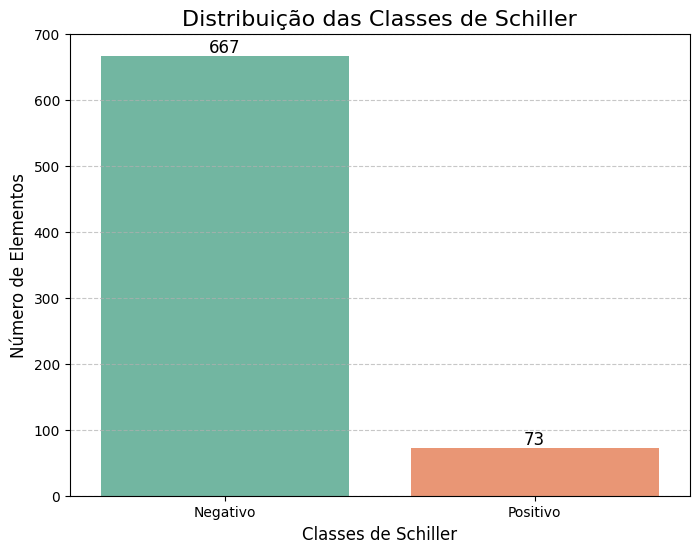

In [ ]:
# Contar os elementos em cada classe de 'Schiller'
class_counts = df_selected['Schiller'].value_counts()

# Exibir os valores
print("Contagem de elementos em cada classe de Schiller:")
print(class_counts)

# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='Set2')

# Exibir os valores sobre as barras
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=12)

# Configurar o gráfico
plt.title('Distribuição das Classes de Schiller', fontsize=16)
plt.xlabel('Classes de Schiller', fontsize=12)
plt.ylabel('Número de Elementos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()


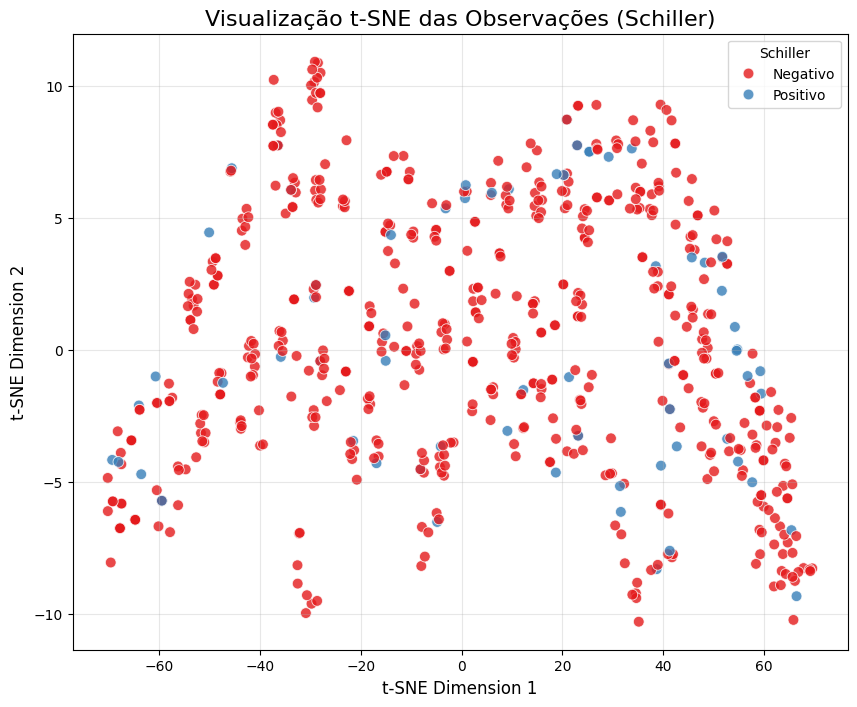

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Separar as variáveis preditoras (X) e a variável alvo (y)
X = df_selected.drop(columns=['Schiller'])
y = df_selected['Schiller']

# Aplicar o t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X)

# Criar um DataFrame com os resultados do t-SNE e a variável alvo
tsne_df = pd.DataFrame(X_embedded, columns=['TSNE1', 'TSNE2'])
tsne_df['Schiller'] = y

# Visualizar os resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Schiller', palette='Set1', s=60, alpha=0.8)
plt.title('Visualização t-SNE das Observações (Schiller)', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Schiller', fontsize=10)
plt.grid(alpha=0.3)
plt.show()


## SMOTE Elevado

Após o pré-processamento dos dados (tratamento de valores ausentes e seleção das variáveis relevantes), aplicamos o algoritmo de balanceamento SMOTE para aumentar o número de observações na classe minoritária (positiva), igualando-o ao número da classe majoritária (negativa).

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Converter todas as colunas de X para float (necessário para o SMOTE)
X = df_selected.drop(columns=['Schiller']).astype(float)
y = df_selected['Schiller']

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Verificar o balanceamento
print("Distribuição após SMOTE:")
print(pd.Series(y_resampled).value_counts())

Distribuição após SMOTE:
Schiller
Negativo    667
Positivo    667
Name: count, dtype: int64


Contagem de elementos em cada classe de Schiller após Smote:
Schiller
Negativo    667
Positivo    667
Name: count, dtype: int64


<ipython-input-210-efcda1bdef44>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='Set2')


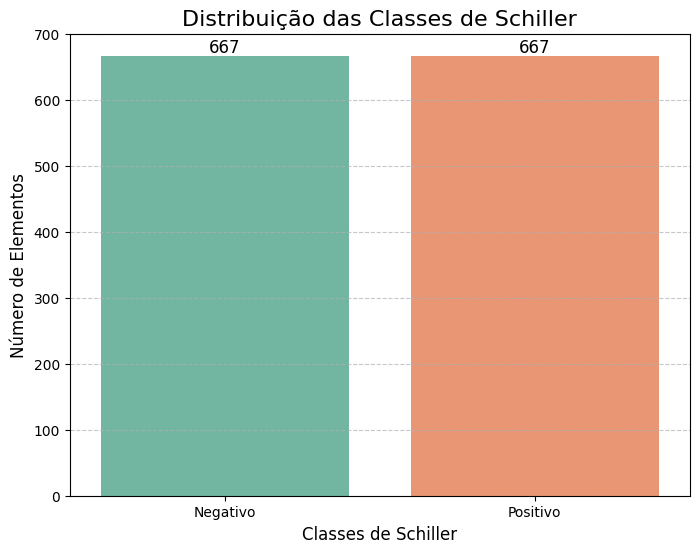

In [ ]:
# Contar os elementos em cada classe de 'Schiller'
class_counts = y_resampled.value_counts()

# Exibir os valores
print("Contagem de elementos em cada classe de Schiller após Smote:")
print(class_counts)

# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='Set2')

# Exibir os valores sobre as barras
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=12)

# Configurar o gráfico
plt.title('Distribuição das Classes de Schiller', fontsize=16)
plt.xlabel('Classes de Schiller', fontsize=12)
plt.ylabel('Número de Elementos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()

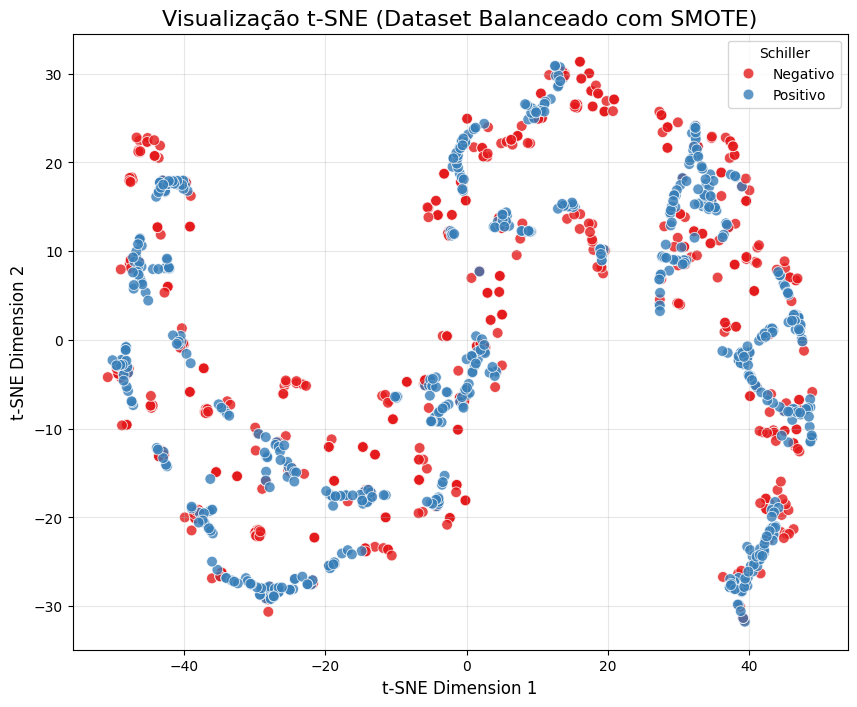

In [ ]:
# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_resampled)

# Criar um DataFrame com os resultados do t-SNE e a variável alvo balanceada
tsne_df = pd.DataFrame(X_embedded, columns=['TSNE1', 'TSNE2'])
tsne_df['Schiller'] = y_resampled

# Visualizar os resultados com t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Schiller', palette='Set1', s=60, alpha=0.8)
plt.title('Visualização t-SNE (Dataset Balanceado com SMOTE)', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Schiller', fontsize=10)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# base de dados balanceada - Contagem de elementos em cada classe de Schiller após Smote:
# Schiller
# Negativo    667
# Positivo    667
# balanced_SMOTEElevado
# Combina X_resampled (variáveis preditoras) e y_resampled (variável alvo) em um único DataFrame
balanced_SMOTE_Elevado = pd.concat(
    [pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='Schiller').reset_index(drop=True)],
    axis=1
)

# Exibe a contagem de elementos em cada classe da variável Schiller
print("Contagem de elementos em cada classe após SMOTE:")
print(balanced_SMOTE_Elevado['Schiller'].value_counts())

# Exibe as primeiras/ultimas linhas do DataFrame para verificar
balanced_SMOTE_Elevado


Contagem de elementos em cada classe após SMOTE:
Schiller
Negativo    667
Positivo    667
Name: count, dtype: int64


,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
0,18.000000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Negativo
1,15.000000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Negativo
2,34.000000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Negativo
3,52.000000,4.000000,37.0,1.000000,0.0,0.0,0.0,0.0,Negativo
4,46.000000,4.000000,0.0,1.000000,0.0,0.0,0.0,0.0,Negativo
...,...,...,...,...,...,...,...,...,...
1329,16.000000,1.000000,0.0,1.000000,0.0,0.0,0.0,0.0,Positivo
1330,33.432055,2.432055,0.0,1.000000,0.0,0.0,0.0,0.0,Positivo
1331,22.000000,1.000000,0.0,0.915488,0.0,0.0,0.0,0.0,Positivo
1332,21.033946,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Positivo


In [ ]:
# Embaralhar usando sample
balanced_SMOTE_Elevado = balanced_SMOTE_Elevado.sample(frac=1, random_state=42)
balanced_SMOTE_Elevado

,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
898,29.759854,3.000000,2.759854,0.240146,0.0,0.000000,0.0,0.0,Positivo
1062,40.375762,2.624238,0.751524,0.624238,0.0,0.000000,0.0,0.0,Positivo
1252,38.000000,2.846967,0.000000,1.000000,0.0,0.000000,0.0,0.0,Positivo
298,19.000000,2.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,Negativo
237,21.000000,1.000000,0.000000,1.000000,0.0,0.000000,0.0,0.0,Negativo
...,...,...,...,...,...,...,...,...,...
1095,33.000000,2.503598,0.251799,1.000000,0.0,0.000000,0.0,0.0,Positivo
1130,39.600997,3.399003,0.000000,1.000000,0.0,0.000000,0.0,0.0,Positivo
1294,38.458176,2.000000,0.000000,1.000000,0.0,0.000000,0.0,0.0,Positivo
860,17.000000,1.328427,0.000000,0.000000,0.0,0.328427,0.0,0.0,Positivo


:## SMOTE com Redução por Seleção Aleatória

Após o pré-processamento dos dados, aplicamos o SMOTE para aumentar o número de observações na classe minoritária (positiva) para o dobro da sua quantidade original (de 73 para 146). Em seguida, reduzimos o número de observações na classe majoritária (negativa), selecionando aleatoriamente um subconjunto com a mesma quantidade da classe positiva.

In [ ]:
from imblearn.over_sampling import SMOTE

# Separar as variáveis preditoras (X) e a variável alvo (y)
# Converter todas as colunas de X para float (necessário para o SMOTE)
X = df_selected.drop(columns=['Schiller']).astype(float)
y = df_selected['Schiller']

# Etapa 1: Aplicar SMOTE para aumentar a classe minoritária para 146
smote = SMOTE(sampling_strategy={'Negativo': 667, 'Positivo': 146}, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combinar os dados resampleados em um DataFrame temporário
resampled_df = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), y_resampled.reset_index(drop=True)], axis=1)

# Etapa 2: Selecionar 146 elementos aleatórios da classe majoritária
# Filtrar as classes
positive_class = resampled_df[resampled_df['Schiller'] == 'Positivo']
negative_class = resampled_df[resampled_df['Schiller'] == 'Negativo']

# Selecionar aleatoriamente 146 elementos da classe majoritária (Negativo)
negative_sample = negative_class.sample(n=146, random_state=42)

# Combinar ambas as classes para formar o novo dataset balanceado
final_df1 = pd.concat([positive_class, negative_sample])

# Resetar o índice para evitar inconsistências
final_df1 = final_df1.reset_index(drop=True)

# Verificar o novo balanceamento
print("Contagem de elementos por classe no novo dataset:")
print(final_df1['Schiller'].value_counts())


Contagem de elementos por classe no novo dataset:
Schiller
Positivo    146
Negativo    146
Name: count, dtype: int64


In [ ]:
# Atribuir o DataFrame final_df a uma nova variável
balanced_SMOTE_Redução_Seleção_Aleatória = final_df1

# Exibir o conteúdo do DataFrame
balanced_SMOTE_Redução_Seleção_Aleatória


,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
0,51.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,Positivo
1,40.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,Positivo
2,40.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,Positivo
3,38.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,Positivo
4,37.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Positivo
...,...,...,...,...,...,...,...,...,...
287,27.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Negativo
288,18.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Negativo
289,29.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Negativo
290,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Negativo


In [ ]:
# Embaralhar usando sample
balanced_SMOTE_Redução_Seleção_Aleatória = balanced_SMOTE_Redução_Seleção_Aleatória.sample(frac=1, random_state=42)
balanced_SMOTE_Redução_Seleção_Aleatória

,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
84,28.0,2.000000,0.280935,0.719065,0.0,0.000000,0.0,0.0,Positivo
260,15.0,1.000000,0.000000,1.000000,0.0,1.000000,0.0,0.0,Negativo
45,20.0,1.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,Positivo
176,25.0,1.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,Negativo
143,38.0,3.779896,0.000000,1.000000,0.0,0.000000,0.0,0.0,Positivo
...,...,...,...,...,...,...,...,...,...
188,37.0,5.000000,0.000000,1.000000,0.0,0.000000,0.0,0.0,Negativo
71,25.0,2.000000,0.000000,1.000000,0.0,0.000000,0.0,0.0,Positivo
106,38.0,2.000000,0.000000,1.000000,0.0,0.000000,0.0,0.0,Positivo
270,33.0,2.000000,4.000000,1.000000,0.0,0.000000,0.0,0.0,Negativo


## SMOTE com Redução via Undersampling

Após o pré-processamento, utilizamos o SMOTE para aumentar o número de observações na classe minoritária (positiva) para o dobro da quantidade original. Em seguida, aplicamos Undersampling à classe majoritária (negativa) para equilibrar as duas classes.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, NearMiss
import pandas as pd

# Separar as variáveis preditoras (X) e a variável alvo (y)
# Converter todas as colunas de X para float (necessário para o SMOTE)
X = df_selected.drop(columns=['Schiller']).astype(float)
y = df_selected['Schiller']

# Etapa 1: Aplicar SMOTE para aumentar a classe minoritária para 146
smote = SMOTE(sampling_strategy={'Negativo': 667, 'Positivo': 146}, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combinar os dados resampleados em um DataFrame temporário
resampled_df = pd.concat(
    [pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='Schiller').reset_index(drop=True)],
    axis=1
)

# Etapa 2: Aplicar undersampling usando Tomek Links
# Separar variáveis preditoras e alvo do DataFrame resampleado
X_resampled = resampled_df.drop(columns=['Schiller'])
y_resampled = resampled_df['Schiller']

# Aplicar Tomek Links
tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X_resampled, y_resampled)

# Combinar os dados após Tomek Links em um DataFrame
tomek_df = pd.concat(
    [pd.DataFrame(X_tomek, columns=X.columns), pd.Series(y_tomek, name='Schiller').reset_index(drop=True)],
    axis=1
)

# Etapa 3: Aplicar undersampling usando NearMiss
# Separar variáveis preditoras e alvo após Tomek Links
X_tomek = tomek_df.drop(columns=['Schiller'])
y_tomek = tomek_df['Schiller']

# Aplicar NearMiss para reduzir ainda mais a classe majoritária
nearmiss = NearMiss(version=3)  # Usar versão 3, que seleciona amostras baseadas na distância média
X_nearmiss, y_nearmiss = nearmiss.fit_resample(X_tomek, y_tomek)

# Combinar os dados após NearMiss em um DataFrame final
final_df3 = pd.concat(
    [pd.DataFrame(X_nearmiss, columns=X.columns), pd.Series(y_nearmiss, name='Schiller').reset_index(drop=True)],
    axis=1
)

# Verificar a nova contagem de elementos por classe
print("Contagem de elementos por classe após Tomek Links e NearMiss:")
print(final_df3['Schiller'].value_counts())


Contagem de elementos por classe após Tomek Links e NearMiss:
Schiller
Negativo    146
Positivo    146
Name: count, dtype: int64


In [ ]:
final_df3

,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
0,70.000000,3.000000,1.0,0.0,0.0,0.0,0.0,0.0,Negativo
1,70.000000,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,Negativo
2,36.000000,2.000000,21.0,0.0,0.0,0.0,0.0,0.0,Negativo
3,59.000000,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,Negativo
4,35.000000,5.000000,19.0,1.0,0.0,0.0,0.0,0.0,Negativo
...,...,...,...,...,...,...,...,...,...
287,16.000000,1.103909,0.0,1.0,0.0,0.0,0.0,0.0,Positivo
288,17.681997,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,Positivo
289,38.000000,3.779896,0.0,1.0,0.0,0.0,0.0,0.0,Positivo
290,19.000000,2.544130,0.0,1.0,0.0,0.0,0.0,0.0,Positivo


In [ ]:
final_df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               292 non-null    float64
 1   Num of pregnancies                292 non-null    float64
 2   Smokes (packs/year)               292 non-null    float64
 3   Hormonal Contraceptives           292 non-null    float64
 4   STDs:HPV                          292 non-null    float64
 5   STDs:syphilis                     292 non-null    float64
 6   STDs:pelvic inflammatory disease  292 non-null    float64
 7   STDs:genital herpes               292 non-null    float64
 8   Schiller                          292 non-null    object 
dtypes: float64(8), object(1)
memory usage: 20.7+ KB


In [ ]:
# Atribuir o DataFrame final_df a uma nova variável
balanced_SMOTE_Redução_Undersampling = final_df3

# Exibir o conteúdo do DataFrame
balanced_SMOTE_Redução_Undersampling


,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
0,70.000000,3.000000,1.0,0.0,0.0,0.0,0.0,0.0,Negativo
1,70.000000,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,Negativo
2,36.000000,2.000000,21.0,0.0,0.0,0.0,0.0,0.0,Negativo
3,59.000000,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,Negativo
4,35.000000,5.000000,19.0,1.0,0.0,0.0,0.0,0.0,Negativo
...,...,...,...,...,...,...,...,...,...
287,16.000000,1.103909,0.0,1.0,0.0,0.0,0.0,0.0,Positivo
288,17.681997,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,Positivo
289,38.000000,3.779896,0.0,1.0,0.0,0.0,0.0,0.0,Positivo
290,19.000000,2.544130,0.0,1.0,0.0,0.0,0.0,0.0,Positivo


In [ ]:
# Embaralha todas as linhas do DataFrame
balanced_SMOTE_Redução_Undersampling = balanced_SMOTE_Redução_Undersampling.sample(frac=1, random_state=42)

# Exibe o DataFrame embaralhado
balanced_SMOTE_Redução_Undersampling



,Age,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives,STDs:HPV,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,Schiller
84,19.0,2.000000,0.0,1.000000,0.0,0.0,0.0,0.0,Negativo
260,21.0,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Positivo
45,39.0,4.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Negativo
176,45.0,4.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Positivo
143,33.0,2.000000,0.0,1.000000,0.0,0.0,0.0,0.0,Negativo
...,...,...,...,...,...,...,...,...,...
188,21.0,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Positivo
71,17.0,2.000000,0.0,0.000000,0.0,0.0,0.0,0.0,Negativo
106,40.0,2.000000,0.0,1.000000,0.0,0.0,0.0,0.0,Negativo
270,21.0,2.092434,0.0,0.907566,0.0,0.0,0.0,0.0,Positivo


## Datasets para Treinamento e Comparação:

Os seguintes datasets foram gerados para treinamento e realização de comparações entre diferentes estratégias de balanceamento:

**balanced_SMOTE_Elevado:**

Dataset obtido utilizando a técnica de oversampling com SMOTE, ampliando a classe minoritária até atingir um equilíbrio com a classe majoritária.

**balanced_SMOTE_Redução_Seleção_Aleatória:**

Dataset balanceado por meio de uma combinação de SMOTE para ampliar a classe minoritária e seleção aleatória para reduzir a classe majoritária, garantindo um equilíbrio exato entre as classes.

**balanced_SMOTE_Redução_Undersampling:**

Dataset gerado a partir de uma estratégia de undersampling aplicada diretamente à classe majoritária após o uso de SMOTE, seguida por um embaralhamento completo dos dados.

### 5 - Treinamento e Comparação dos Modelos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Converter 'Schiller' para valores numéricos
balanced_SMOTE_Elevado['Schiller'] =  balanced_SMOTE_Elevado['Schiller'].map({'Negativo': 0, 'Positivo': 1})
balanced_SMOTE_Redução_Seleção_Aleatória['Schiller'] =  balanced_SMOTE_Redução_Seleção_Aleatória['Schiller'].map({'Negativo': 0, 'Positivo': 1})
balanced_SMOTE_Redução_Undersampling['Schiller'] = balanced_SMOTE_Redução_Undersampling['Schiller'].map({'Negativo': 0, 'Positivo': 1})


Resultados para o dataset: SMOTE Elevado
Modelo 1: Acurácia média = 0.5420


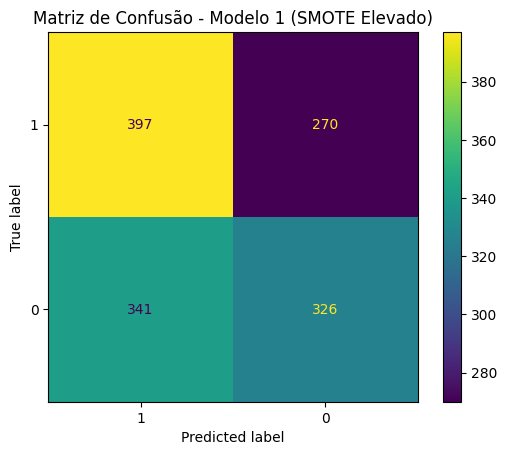

Modelo 2: Acurácia média = 0.8936


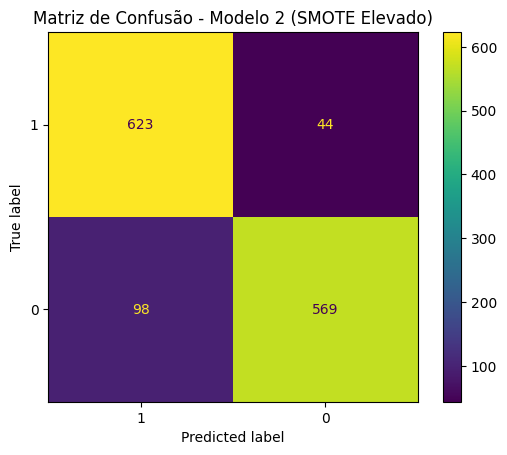

Modelo 3: Acurácia média = 0.8988


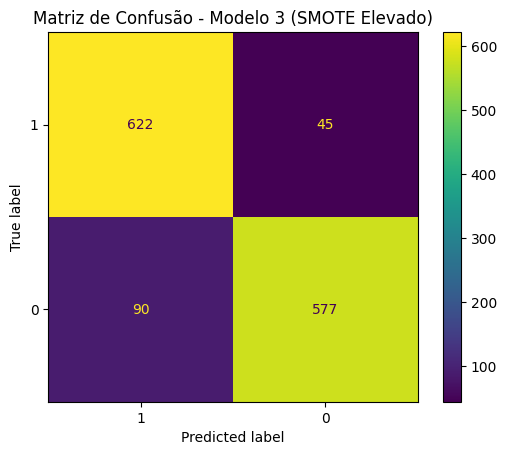

Modelo 4: Acurácia média = 0.8119


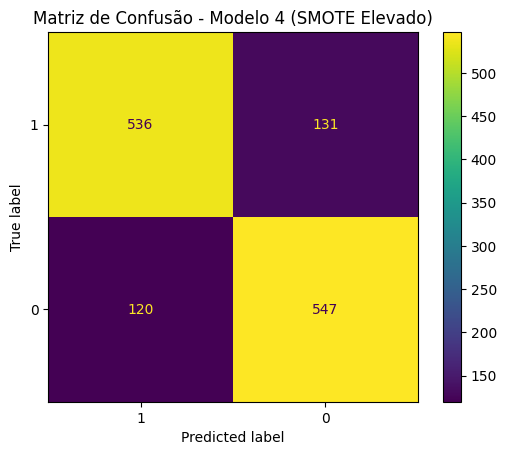

Modelo 5: Acurácia média = 0.9003


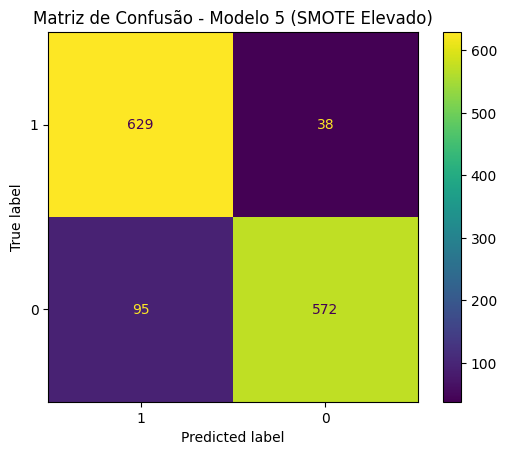


Resultados para o dataset: SMOTE Redução Seleção Aleatória
Modelo 1: Acurácia média = 0.5377


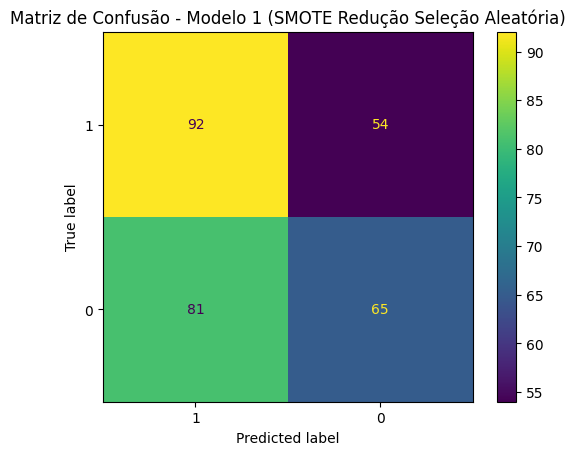

Modelo 2: Acurácia média = 0.7398


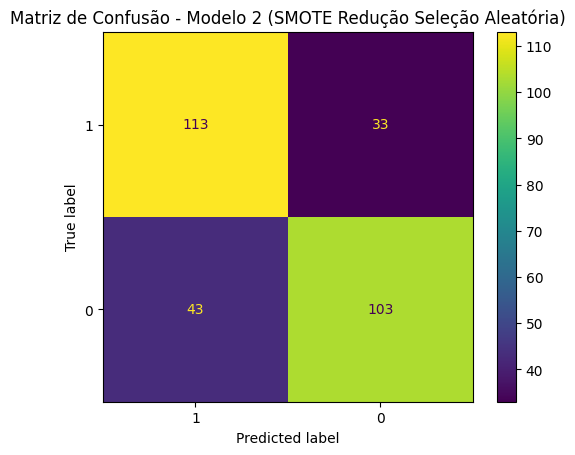

Modelo 3: Acurácia média = 0.7672


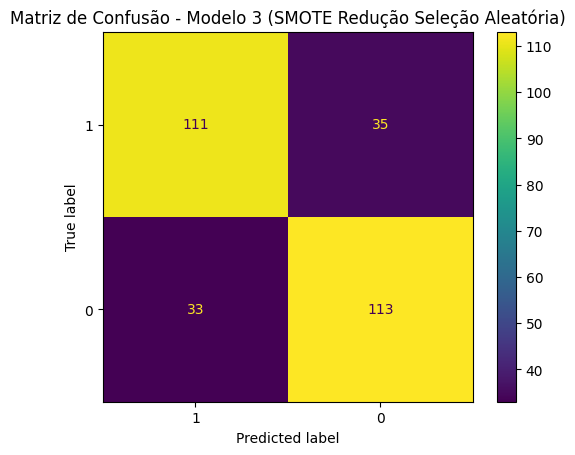

Modelo 4: Acurácia média = 0.6400


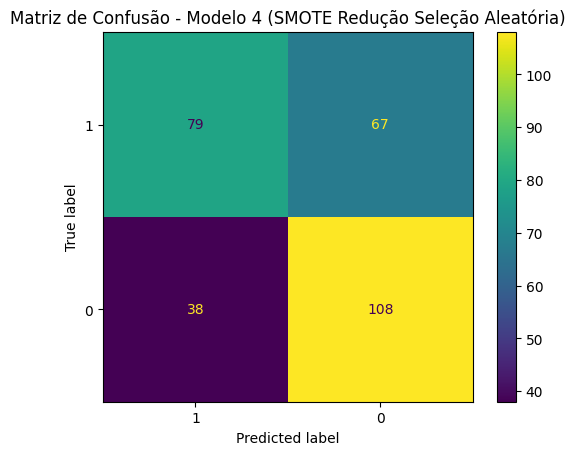

Modelo 5: Acurácia média = 0.7602


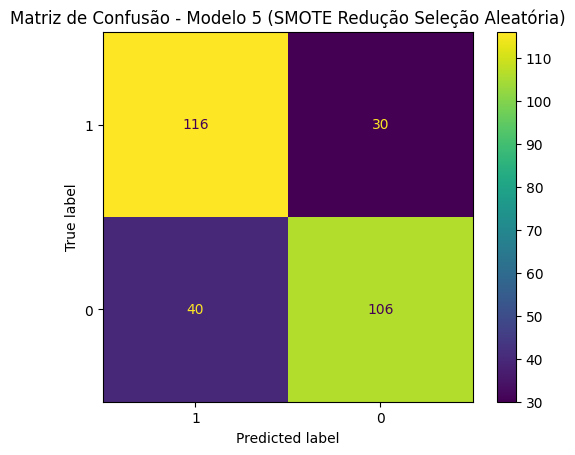


Resultados para o dataset: SMOTE Redução Undersampling
Modelo 1: Acurácia média = 0.5309


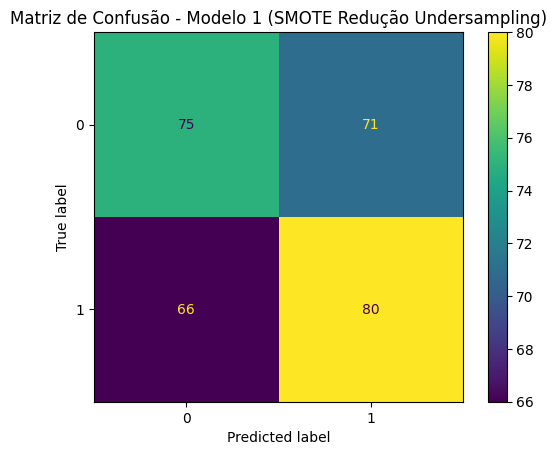

Modelo 2: Acurácia média = 0.7434


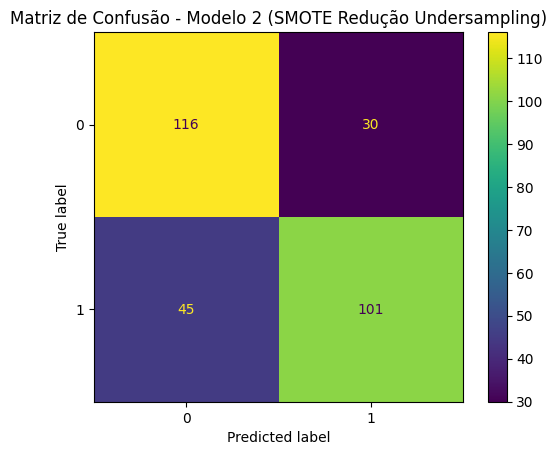

Modelo 3: Acurácia média = 0.7432


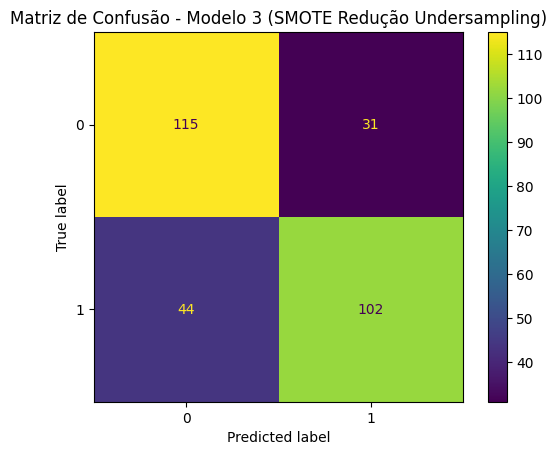

Modelo 4: Acurácia média = 0.5717


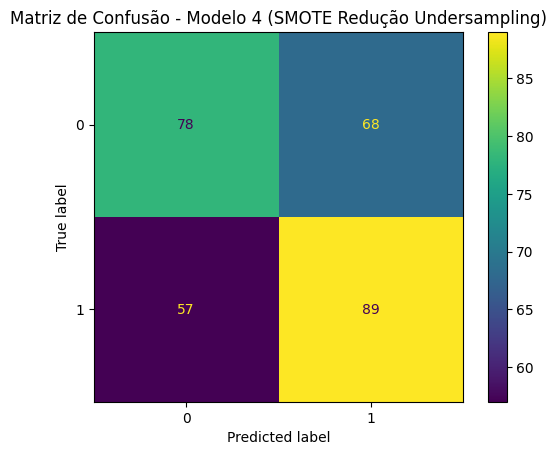

Modelo 5: Acurácia média = 0.7330


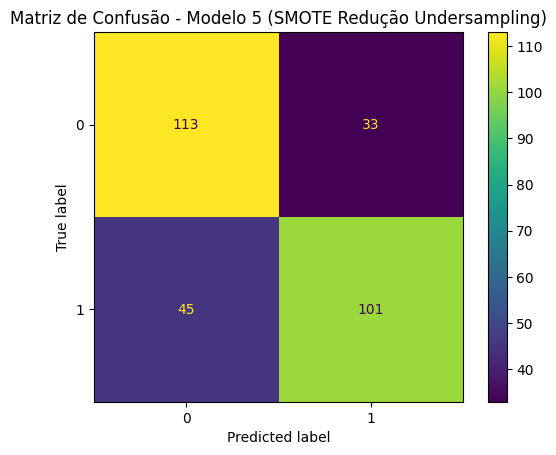


Tabela de Resultados:
                      Base de Dados  Modelo  \
0                     SMOTE Elevado       1   
1                     SMOTE Elevado       2   
2                     SMOTE Elevado       3   
3                     SMOTE Elevado       4   
4                     SMOTE Elevado       5   
5   SMOTE Redução Seleção Aleatória       1   
6   SMOTE Redução Seleção Aleatória       2   
7   SMOTE Redução Seleção Aleatória       3   
8   SMOTE Redução Seleção Aleatória       4   
9   SMOTE Redução Seleção Aleatória       5   
10      SMOTE Redução Undersampling       1   
11      SMOTE Redução Undersampling       2   
12      SMOTE Redução Undersampling       3   
13      SMOTE Redução Undersampling       4   
14      SMOTE Redução Undersampling       5   

    Avaliar acurácia com validação cruzada  
0                                 0.542015  
1                                 0.893581  
2                                 0.898827  
3                                 0.811851  

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Função para obter o modelo
def getModel(model_code=1):
    """
    Retorna o modelo especificado com os parâmetros predefinidos.

    Parâmetros:
        model_code (int): Código do modelo desejado. Valores possíveis:
            - 1: Logistic Regression
            - 2: Decision Tree
            - 3: Random Forest
            - 4: K-Nearest Neighbors (KNN)
            - 5: XGBoost

    Retorno:
        Um modelo de machine learning configurado com parâmetros predefinidos.
    """
    if model_code == 1:
        return LogisticRegression(random_state=42, max_iter=1000)  # Aumentado max_iter
    elif model_code == 2:
        return DecisionTreeClassifier(random_state=42)
    elif model_code == 3:
        return RandomForestClassifier(random_state=42)
    elif model_code == 4:
        return KNeighborsClassifier(n_neighbors=5)
    elif model_code == 5:
        return XGBClassifier(eval_metric='logloss', random_state=42)
    else:
        raise ValueError("Código de modelo não reconhecido. Escolha entre: 1, 2, 3, 4, 5.")

# Datasets balanceados
datasets = {
    "SMOTE Elevado": balanced_SMOTE_Elevado,
    "SMOTE Redução Seleção Aleatória": balanced_SMOTE_Redução_Seleção_Aleatória,
    "SMOTE Redução Undersampling": balanced_SMOTE_Redução_Undersampling
}

# Para armazenar os resultados de acurácia
results = []

# Loop para cada base de dados balanceada
for dataset_name, dataset in datasets.items():
    print(f"\nResultados para o dataset: {dataset_name}")

    X = dataset.drop(columns=['Schiller'])
    y = dataset['Schiller']

    # Loop para cada modelo
    for model_code in range(1, 6):
        # Obter modelo
        model = getModel(model_code)

        # Avaliar acurácia com validação cruzada
        scores = cross_val_score(model, X, y, cv=10)
        mean_accuracy = scores.mean()
        print(f"Modelo {model_code}: Acurácia média = {mean_accuracy:.4f}")

        # Adicionar resultado à tabela
        results.append({
            "Base de Dados": dataset_name,
            "Modelo": model_code,
            "Avaliar acurácia com validação cruzada": mean_accuracy
        })

        # Gerar predições com validação cruzada
        predicoes = cross_val_predict(model, X, y, cv=10)

        # Criar matriz de confusão
        cm = confusion_matrix(y, predicoes)

        # Exibir matriz de confusão
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y.unique())
        disp.plot()
        plt.title(f"Matriz de Confusão - Modelo {model_code} ({dataset_name})")
        plt.show()

# Criar tabela de resultados
results_table = pd.DataFrame(results)

# Exibir a tabela
print("\nTabela de Resultados:")
print(results_table)


In [ ]:
# Criar um mapeamento para substituir os códigos pelos nomes dos modelos
model_mapping = {
    1: "Logistic Regression",
    2: "Decision Tree",
    3: "Random Forest",
    4: "K-Nearest Neighbors",
    5: "XGBoost"
}

# Substituir os códigos pelos nomes dos modelos na tabela de resultados
results_table["Modelo"] = results_table["Modelo"].map(model_mapping)

# Exibir a tabela final
print("\nTabela de Resultados (com nomes dos modelos):")
results_table



Tabela de Resultados (com nomes dos modelos):


,Base de Dados,Modelo,Avaliar acurácia com validação cruzada
0,SMOTE Elevado,Logistic Regression,0.542015
1,SMOTE Elevado,Decision Tree,0.893581
2,SMOTE Elevado,Random Forest,0.898827
3,SMOTE Elevado,K-Nearest Neighbors,0.811851
4,SMOTE Elevado,XGBoost,0.900314
5,SMOTE Redução Seleção Aleatória,Logistic Regression,0.537701
6,SMOTE Redução Seleção Aleatória,Decision Tree,0.739770
7,SMOTE Redução Seleção Aleatória,Random Forest,0.767241
8,SMOTE Redução Seleção Aleatória,K-Nearest Neighbors,0.640000
9,SMOTE Redução Seleção Aleatória,XGBoost,0.760230


## 6 - Resultados:

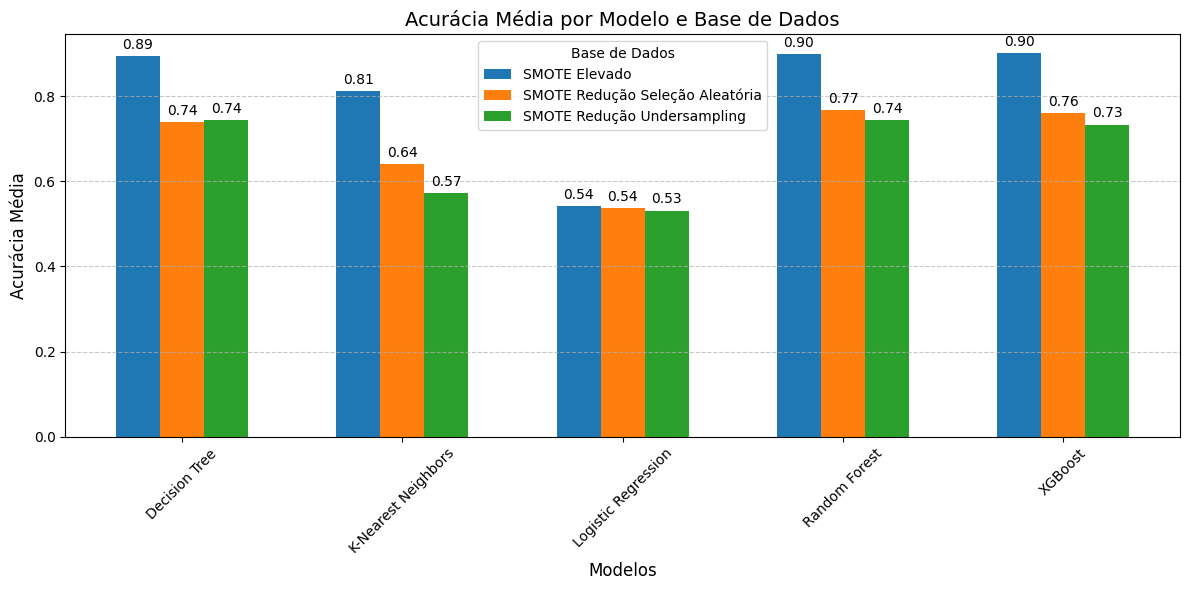

In [ ]:
# Pivotar a tabela para organizar os dados por agrupamento de modelo e base de dados
pivot_table = results_table.pivot(index="Modelo", columns="Base de Dados", values="Avaliar acurácia com validação cruzada")

# Configurar o gráfico
plt.figure(figsize=(12, 6))

# Configurar largura e posições das barras
bar_width = 0.2
index = np.arange(len(pivot_table.index))  # Índices para os modelos

# Criar barras para cada base de dados
for i, dataset_name in enumerate(pivot_table.columns):
    bars = plt.bar(
        index + i * bar_width,
        pivot_table[dataset_name],
        bar_width,
        label=dataset_name
    )

    # Adicionar rótulos nas barras
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):  # Adicionar rótulo apenas se houver um valor válido
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01,  # Posição do texto acima da barra
                f"{height:.2f}",  # Formatar o valor
                ha="center", va="bottom", fontsize=10
            )

# Configurações do gráfico
plt.title("Acurácia Média por Modelo e Base de Dados", fontsize=14)
plt.xlabel("Modelos", fontsize=12)
plt.ylabel("Acurácia Média", fontsize=12)
plt.xticks(index + bar_width, pivot_table.index, rotation=45)  # Nomes dos modelos
plt.legend(title="Base de Dados", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Exibir o gráfico
plt.tight_layout()
plt.show()


## Link para um artigo para comparação com os nossos resultados

https://www.mdpi.com/2079-9292/11/3/463

MDPI and ACS Style

Tanimu, J.J.; Hamada, M.; Hassan, M.; Kakudi, H.; Abiodun, J.O. A Machine Learning Method for Classification of Cervical Cancer. Electronics 2022, 11, 463. https://doi.org/10.3390/electronics11030463

OBS.: Das variáveis que você utilizou no seu trabalho, 75% delas estão presentes no artigo. Isso demonstra uma forte convergência entre as escolhas feitas no seu modelo e as variáveis consideradas relevantes no estudo do artigo.

## Outros Teste - Treinos

In [ ]:
def getModel1():
    #return LogisticRegression()
    #return DecisionTreeClassifier()
    #return RandomForestClassifier()
    #return KNeighborsClassifier(n_neighbors=5)
    return XGBClassifier(eval_metric='logloss',random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split

# Separar X (variáveis preditoras) e y (variável alvo)
X = balanced_SMOTE_Redução_Undersampling.drop(columns=['Schiller']).values
y = balanced_SMOTE_Redução_Undersampling['Schiller'].values

# Dividir o dataset em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
modelo = getModel1().fit(X_treino,y_treino)

score = modelo.score(X_teste,y_teste)

score

0.6610169491525424

VALIDAÇÃO DE FORMA MAIS ELABORADA

In [ ]:
scores = cross_val_score(getModel1(),X,y,cv=10)

scores.mean()

0.7329885057471264

 MATRIZ DE CONFUSÃO

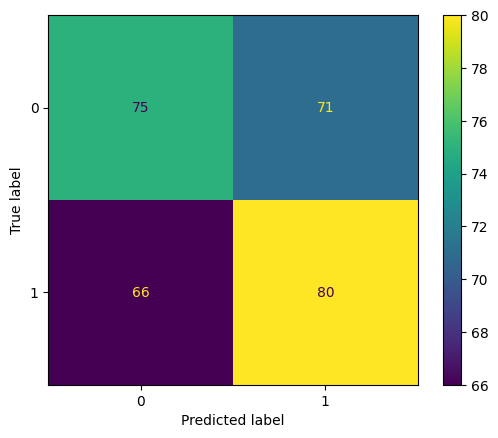

In [ ]:
predicoes = cross_val_predict(getModel(),X,y,cv=10)

cm = confusion_matrix(y, predicoes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=modelo.classes_)
disp.plot()

plt.show()